<a href="https://colab.research.google.com/github/brugerard/Test/blob/Predoc2026/DorinV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

|    | Country         | Years     |   Δlog AgWorkers (X_end) |   Δ ‘gap improvement’ (Y_end) |   FD score |
|----|-----------------|-----------|--------------------------|-------------------------------|------------|
|  0 | Yemen, Rep.     | 2000-2018 |                   -0.149 |                         1.717 |      1.672 |
|  1 | Algeria         | 2000-2023 |                   -0.496 |                         1.551 |      1.402 |
|  2 | Slovak Republic | 2000-2023 |                   -0.951 |                         1.74  |      1.279 |
|  3 | Comoros         | 2000-2023 |                    0.293 |                         1.241 |      1.153 |
|  4 | Rwanda          | 2000-2023 |                    0.211 |                         1.145 |      1.082 |
|  5 | Senegal         | 2000-2023 |                   -0.141 |                         1.105 |      1.063 |
|  6 | Benin           | 2000-2023 |                    0.157 |                         1.072 |      1.025 |
|  7 | Paraguay    

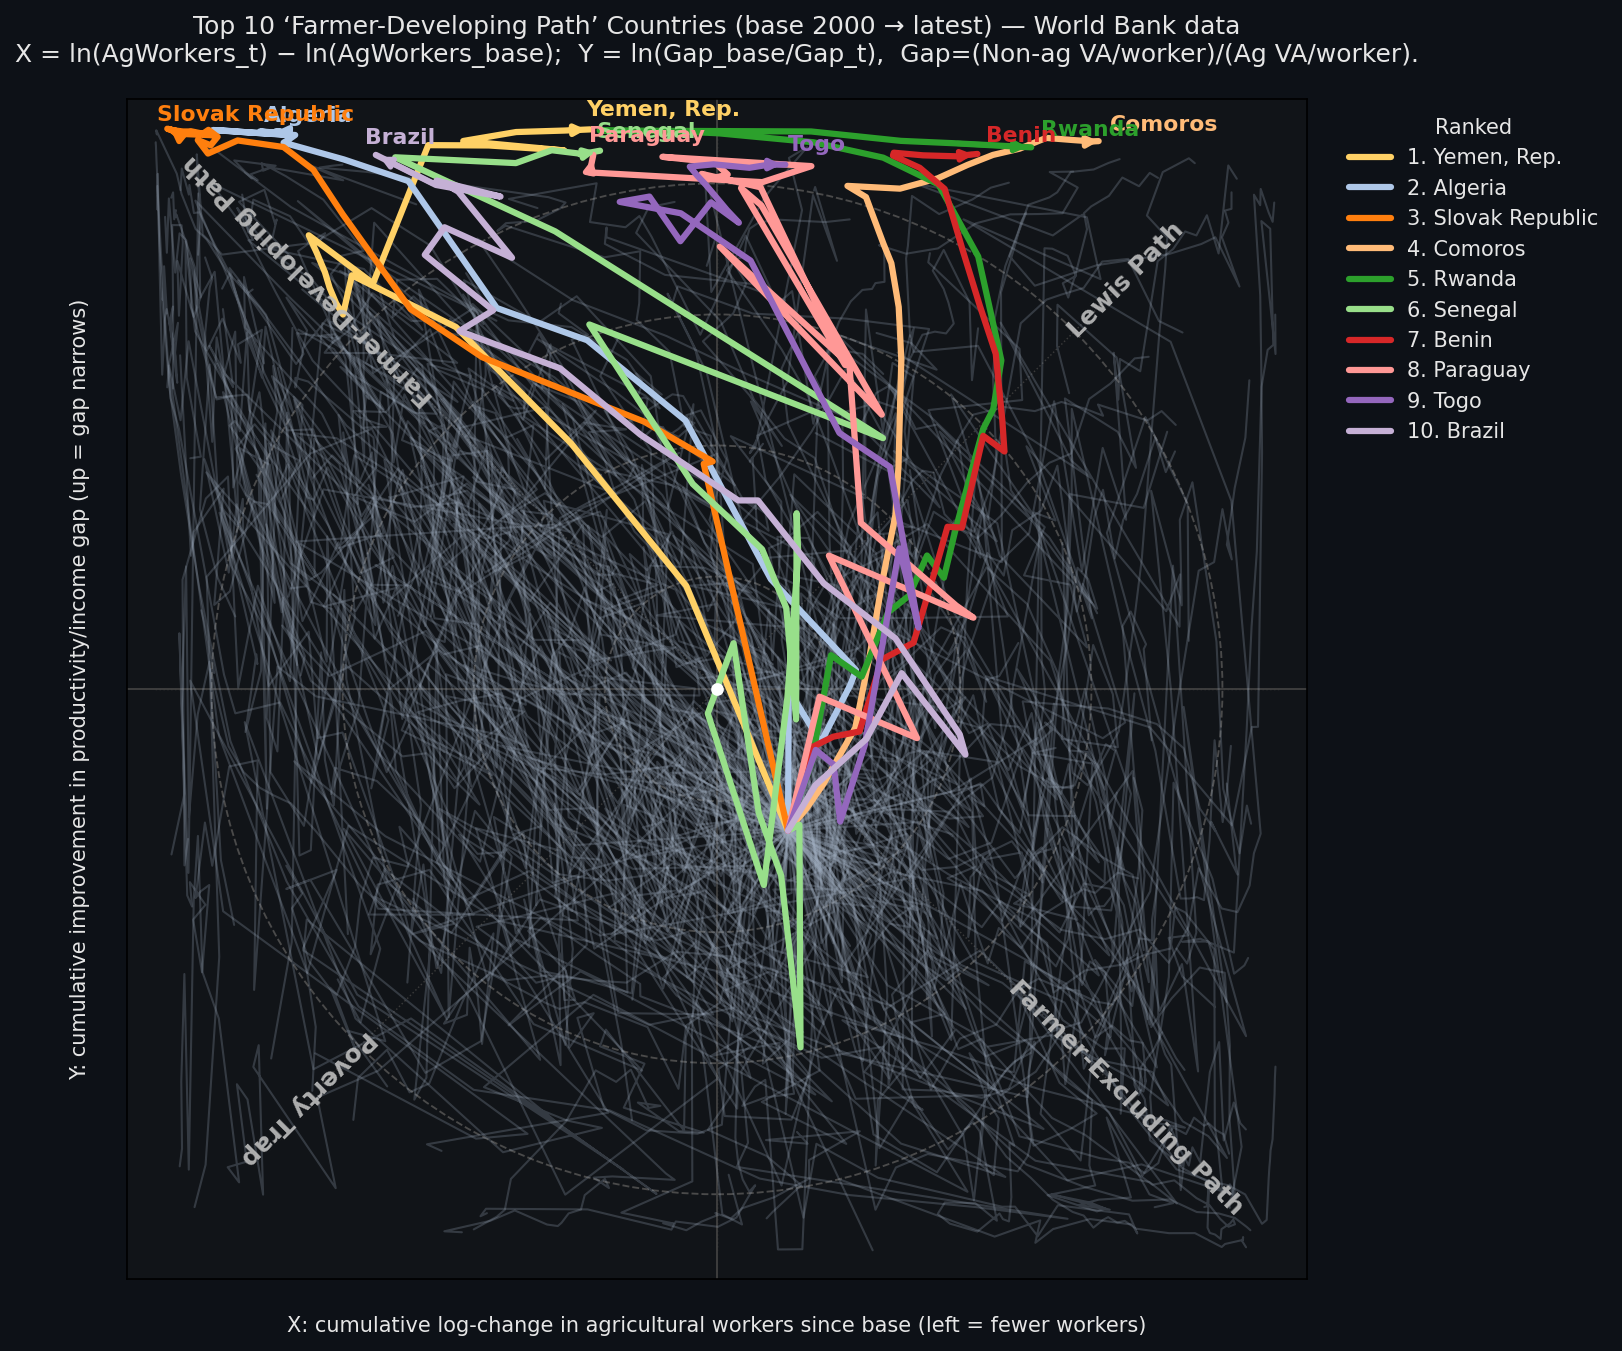

In [ ]:
# %pip install -q requests pandas numpy matplotlib tabulate

import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from tabulate import tabulate

# ----------------------- Parameters -----------------------
BASE_YEAR = 2000            # base for cumulative changes
START, END = 1995, 2023     # pull window (we'll clip to BASE_YEAR..END)
MIN_YEARS = 12              # require at least this many valid years
TOP_K = 10                  # show top-K FD countries

# World Bank indicators
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",  # Agriculture, value added (constant 2015 US$)
    "AGVA_pct":   "NV.AGR.TOTL.ZS",  # Agriculture, value added (% of GDP)  [not used directly here]
    "GDP_const":  "NY.GDP.MKTP.KD",  # GDP (constant 2015 US$)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",  # Labor force, total (active population)
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS"   # Employment in agriculture (% of total employment)
}

# ----------------------- WB helpers -----------------------
def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value"])
    rows = [{"Year": int(d["date"]), "Value": d["value"]}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

def wb_countries_world():
    url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
    js = wb_get(url)
    rows = []
    for d in js[1]:
        # remove aggregates: region id "NA" or id length != 3
        if d.get("region", {}).get("id") == "NA":
            continue
        if len(d["id"]) != 3:
            continue
        rows.append({"iso3": d["id"], "name": d["name"], "region": d["region"]["value"]})
    return pd.DataFrame(rows)

# ----------------------- Compute X/Y (Dorin) -----------------------
def series_dorin_axes(iso3):
    """Returns DataFrame with Year, X (cum log-change in AgWorkers from base),
       Y (cum improvement in productivity gap), plus raw columns used."""
    agva  = wb_indicator(iso3, IND["AGVA_const"])
    gdp   = wb_indicator(iso3, IND["GDP_const"])
    lf    = wb_indicator(iso3, IND["LAB_FORCE"])
    agemp = wb_indicator(iso3, IND["AG_EMP_PCT"])
    if any(df.empty for df in [agva, gdp, lf, agemp]):
        return pd.DataFrame()

    df = (agva.rename(columns={"Value":"AgVA"})
              .merge(gdp.rename(columns={"Value":"GDP"}), on="Year", how="inner")
              .merge(lf.rename(columns={"Value":"LaborForce"}), on="Year", how="inner")
              .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on="Year", how="inner"))

    df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
    if df.empty:
        return pd.DataFrame()

    # Construct worker counts & per-worker values
    df["AgWorkers"]   = df["LaborForce"] * (df["AgEmpPct"]/100.0)
    df = df[df["AgWorkers"]>0]
    if df.shape[0] < MIN_YEARS:
        return pd.DataFrame()

    df["NonAgWorkers"] = df["LaborForce"] - df["AgWorkers"]
    df = df[df["NonAgWorkers"]>0]
    if df.shape[0] < MIN_YEARS:
        return pd.DataFrame()

    df["AgPW"]    = df["AgVA"] / df["AgWorkers"]
    df["NonAgPW"] = (df["GDP"] - df["AgVA"]) / df["NonAgWorkers"]
    df = df[(df["AgPW"]>0) & (df["NonAgPW"]>0)]
    if df.shape[0] < MIN_YEARS:
        return pd.DataFrame()

    df = df[(df["Year"]>=BASE_YEAR) & (df["Year"]<=END)].sort_values("Year")
    if df.shape[0] < MIN_YEARS:
        return pd.DataFrame()

    # Base year = first available >= BASE_YEAR
    base_row = df.iloc[0]
    lnAgW_base   = np.log(base_row["AgWorkers"])
    lnGap_base   = np.log(base_row["NonAgPW"] / base_row["AgPW"])

    # Cumulative changes from base
    df["X"] = np.log(df["AgWorkers"]) - lnAgW_base                       # cum log-change in AgWorkers
    df["Y"] = (lnGap_base - np.log(df["NonAgPW"]/df["AgPW"]))            # cum improvement in gap (up = gap narrows)

    # Keep essentials
    return df[["Year","X","Y","AgPW","NonAgPW","AgWorkers","NonAgWorkers"]]

# ----------------------- Scan all countries, rank FD -----------------------
countries = wb_countries_world()
lines = []
summary = []

for iso, cname in countries[["iso3","name"]].itertuples(index=False):
    s = series_dorin_axes(iso)
    if s.empty:
        continue
    lines.append({"Country": cname, "iso3": iso, "series": s})

    # endpoints for scoring (use last year available)
    s2 = s.dropna(subset=["X","Y"]).sort_values("Year")
    x_end = float(s2["X"].iloc[-1])
    y_end = float(s2["Y"].iloc[-1])

    # FD score: big Y (gap narrows) and avoid **very** negative X (massive exodus).
    # Penalize strong negative X below -0.7 (approx -50% workers), and large |X|.
    penalty = 0.7*max((-x_end - 0.7), 0) + 0.3*abs(x_end)
    score = y_end - penalty

    # Store mid & end ag employment share for context
    # We can back out ag share using workers counts (but not needed for scoring).
    summary.append({
        "Country": cname, "iso3": iso,
        "Years": f"{int(s2['Year'].iloc[0])}-{int(s2['Year'].iloc[-1])}",
        "X_end": x_end, "Y_end": y_end, "FD_score": score
    })

rank = (pd.DataFrame(summary)
          .sort_values("FD_score", ascending=False)
          .reset_index(drop=True))

top = rank.head(TOP_K).copy()

# Pretty print table
tbl = top.copy()
tbl["Δlog AgWorkers (X_end)"] = tbl["X_end"].round(3)
tbl["Δ ‘gap improvement’ (Y_end)"] = tbl["Y_end"].round(3)
tbl["FD score"] = tbl["FD_score"].round(3)
print(tabulate(tbl[["Country","Years","Δlog AgWorkers (X_end)","Δ ‘gap improvement’ (Y_end)","FD score"]],
               headers="keys", tablefmt="github", showindex=True))

# ----------------------- Plot: highlight Top-K -----------------------
def draw_concentric(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)

plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})

fig = plt.figure(figsize=(10.5, 10.5), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")
draw_concentric(ax, radii=np.linspace(0.2,0.9,4))
ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

# Quadrant labels (following Dorin framing; up = gap narrows; left = fewer ag workers)
for txt, deg in [
    ("Farmer-Developing Path", 135),
    ("Lewis Path",               45),
    ("Farmer-Excluding Path",  -45),
    ("Poverty Trap",           -135),
]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=12, rotation=deg, rotation_mode="anchor",
            color="#BFBFBF", weight="bold", alpha=0.9)

# Build global squash parameters for display (keep geometry consistent within this plot)
allX = np.concatenate([d["series"]["X"].values for d in lines])
allY = np.concatenate([d["series"]["Y"].values for d in lines])
X_MEAN, X_STD = np.nanmean(allX), np.nanstd(allX)
Y_MEAN, Y_STD = np.nanmean(allY), np.nanstd(allY)

def squash_fixed(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

top_set = set(top["Country"])
BASE_COL = "#A0AEC0"
def color_for(i):
    # cycle tab20 with one highlight color for rank #1
    return "#FFD166" if i == 0 else plt.cm.tab20(i % 20)

# Draw all faint
for L in lines:
    s = L["series"].sort_values("Year")
    xx = squash_fixed(s["X"].values, X_MEAN, X_STD)
    yy = squash_fixed(s["Y"].values, Y_MEAN, Y_STD)
    ax.plot(xx, yy, color=BASE_COL, lw=1.0, alpha=0.25, solid_capstyle="round")

# Highlight Top-K with labels and arrows
for i, row in top.iterrows():
    name = row["Country"]
    s = [L for L in lines if L["Country"]==name][0]["series"].sort_values("Year")
    xx = squash_fixed(s["X"].values, X_MEAN, X_STD)
    yy = squash_fixed(s["Y"].values, Y_MEAN, Y_STD)
    col = color_for(i)
    ax.plot(xx, yy, color=col, lw=3.0, solid_capstyle="round", label=f"{i+1}. {name}")
    if len(xx) >= 2:
        ax.annotate("", xy=(xx[-1],yy[-1]), xytext=(xx[-2],yy[-2]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.6, mutation_scale=10))
        # label off the arrow
        theta = math.atan2(yy[-1], xx[-1]); off=0.035
        ax.text(xx[-1]+off*math.cos(theta), yy[-1]+off*math.sin(theta),
                name, color=col, fontsize=10.5, weight="bold", va="center")

# Origin + labels
ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("X: cumulative log-change in agricultural workers since base (left = fewer workers)", labelpad=18)
ax.set_ylabel("Y: cumulative improvement in productivity/income gap (up = gap narrows)", labelpad=18)

ax.set_title(
    f"Top {TOP_K} ‘Farmer-Developing Path’ Countries (base {BASE_YEAR} → latest) — World Bank data\n"
    "X = ln(AgWorkers_t) − ln(AgWorkers_base);  Y = ln(Gap_base/Gap_t),  Gap=(Non-ag VA/worker)/(Ag VA/worker).",
    fontsize=12, pad=18, color="#E6E6E6"
)

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Ranked")
plt.tight_layout()
plt.show()

| Country      | Years     |   Δlog AgWorkers (X_end) |   Δ ‘gap improvement’ (Y_end) |
|--------------|-----------|--------------------------|-------------------------------|
| Egypt        | 2000-2023 |                   -0.019 |                         0.368 |
| France       | 2000-2023 |                   -0.357 |                         0.324 |
| India        | 2000-2023 |                    0.048 |                        -0.12  |
| Morocco      | 2000-2023 |                   -0.192 |                         0.778 |
| Niger        | 2000-2023 |                    0.627 |                         0.899 |
| Nigeria      | 2000-2023 |                    0.26  |                         0.939 |
| South Africa | 2000-2023 |                    0.291 |                         0.199 |
| Zimbabwe     | 2000-2023 |                    0.098 |                         0.196 |


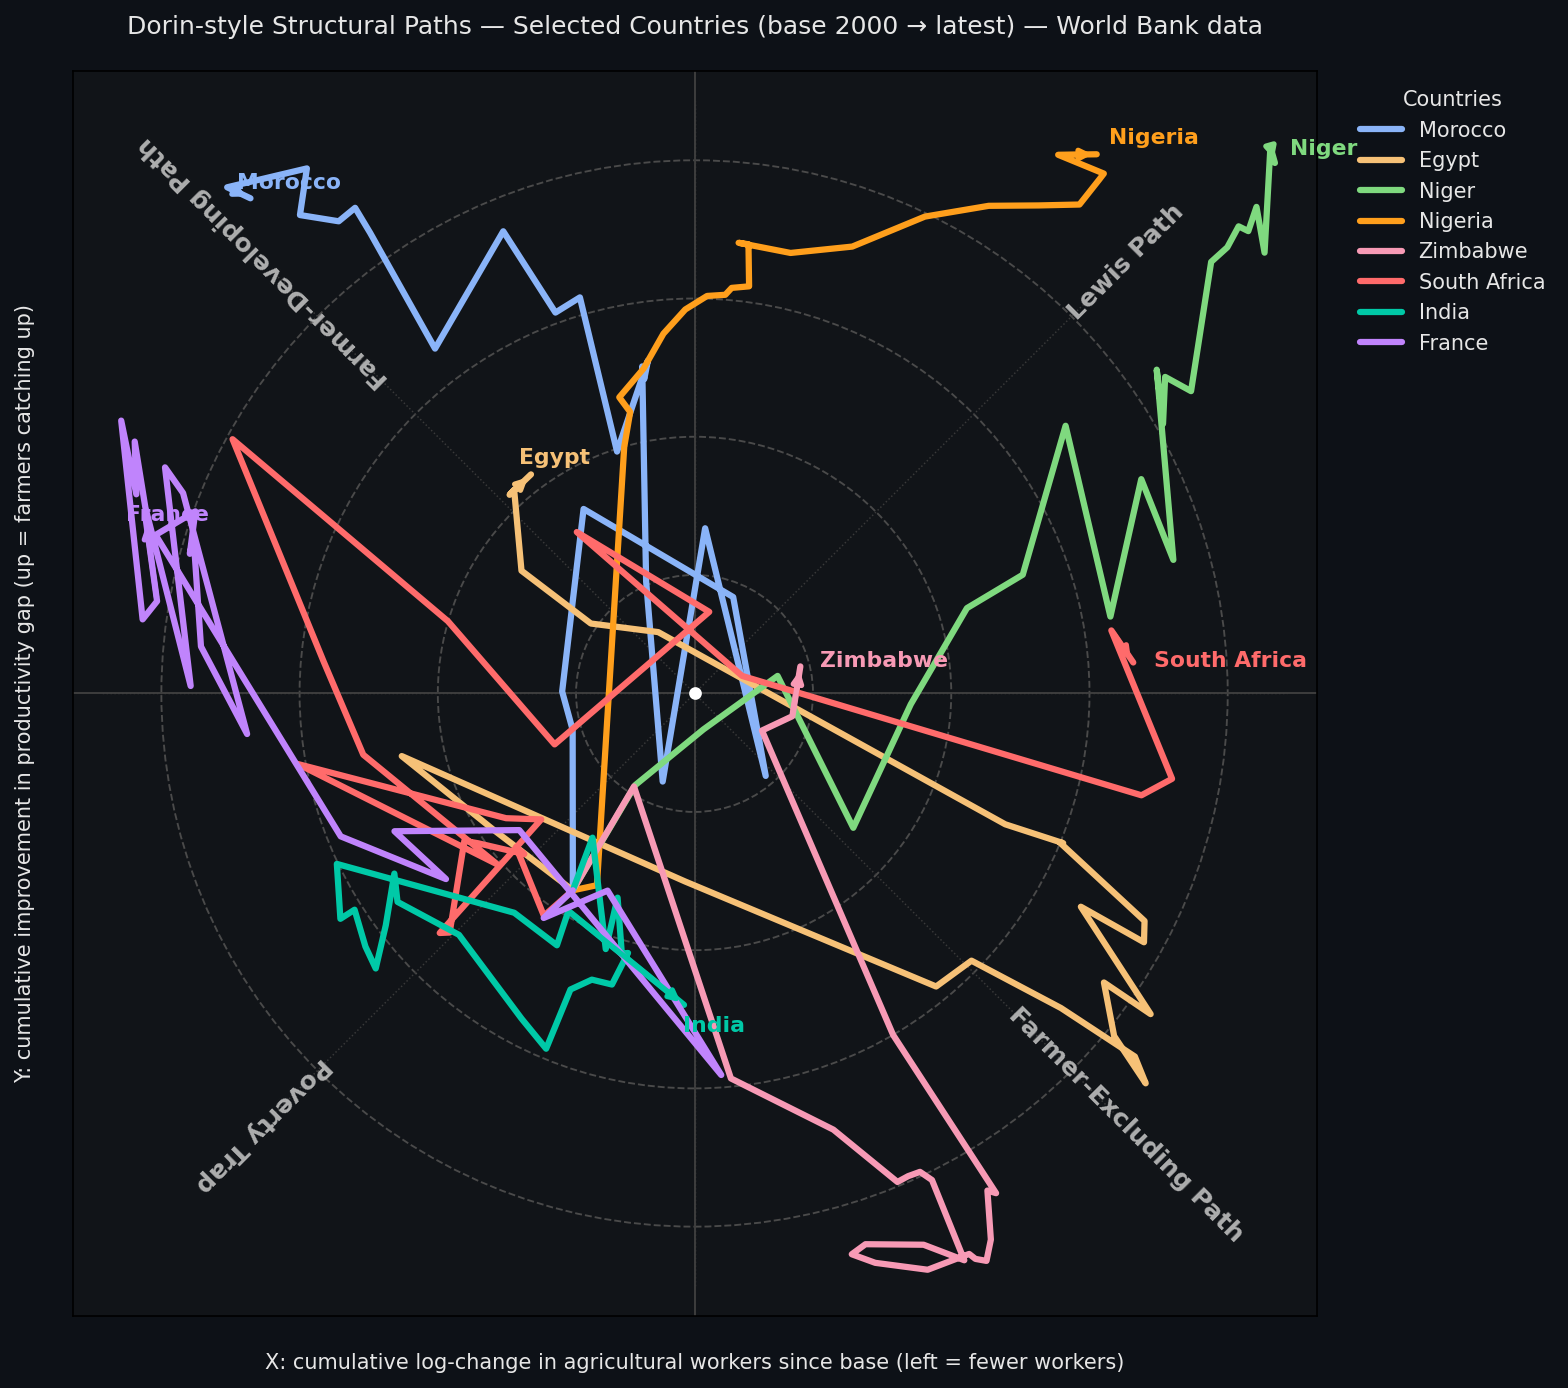

In [ ]:
# %pip install -q requests pandas numpy matplotlib tabulate

import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from tabulate import tabulate

# ------------------ Parameters ------------------
BASE_YEAR = 2000
START, END = 1995, 2023
MIN_YEARS = 10  # per-country minimum years after filters

COUNTRIES = {
    "Morocco": "MAR",
    "Egypt": "EGY",
    "Niger": "NER",
    "Nigeria": "NGA",
    "Zimbabwe": "ZWE",
    "South Africa": "ZAF",
    "India": "IND",
    "France": "FRA",
}

# World Bank indicators
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",  # Agriculture, value added (constant 2015 US$)
    "GDP_const":  "NY.GDP.MKTP.KD",  # GDP (constant 2015 US$)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",  # Labor force, total
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",  # Employment in agriculture (% of total employment)
}

# ------------------ WB helpers ------------------
def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value"])
    rows = [{"Year": int(d["date"]), "Value": d["value"]}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

# ------------------ Dorin axes per country ------------------
def series_dorin_axes(iso3):
    agva  = wb_indicator(iso3, IND["AGVA_const"])
    gdp   = wb_indicator(iso3, IND["GDP_const"])
    lf    = wb_indicator(iso3, IND["LAB_FORCE"])
    agemp = wb_indicator(iso3, IND["AG_EMP_PCT"])
    if any(df.empty for df in [agva, gdp, lf, agemp]):
        return pd.DataFrame()

    df = (agva.rename(columns={"Value":"AgVA"})
              .merge(gdp.rename(columns={"Value":"GDP"}), on="Year", how="inner")
              .merge(lf.rename(columns={"Value":"LaborForce"}), on="Year", how="inner")
              .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on="Year", how="inner"))
    df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
    if df.empty: return pd.DataFrame()

    df["AgWorkers"]   = df["LaborForce"] * (df["AgEmpPct"]/100.0)
    df = df[df["AgWorkers"]>0]
    if df.shape[0] < MIN_YEARS: return pd.DataFrame()

    df["NonAgWorkers"] = df["LaborForce"] - df["AgWorkers"]
    df = df[df["NonAgWorkers"]>0]
    if df.shape[0] < MIN_YEARS: return pd.DataFrame()

    df["AgPW"]    = df["AgVA"] / df["AgWorkers"]
    df["NonAgPW"] = (df["GDP"] - df["AgVA"]) / df["NonAgWorkers"]
    df = df[(df["AgPW"]>0) & (df["NonAgPW"]>0)]
    if df.shape[0] < MIN_YEARS: return pd.DataFrame()

    df = df[(df["Year"]>=BASE_YEAR) & (df["Year"]<=END)].sort_values("Year")
    if df.shape[0] < MIN_YEARS: return pd.DataFrame()

    # base at first available >= BASE_YEAR
    base = df.iloc[0]
    lnAgW0 = np.log(base["AgWorkers"])
    lnGap0 = np.log(base["NonAgPW"]/base["AgPW"])

    df["X"] = np.log(df["AgWorkers"]) - lnAgW0                         # cum log-change in ag workers
    df["Y"] = (lnGap0 - np.log(df["NonAgPW"]/df["AgPW"]))              # cum improvement in gap

    return df[["Year","X","Y","AgWorkers","AgPW","NonAgPW"]]

# ------------------ Pull & summarize ------------------
lines = []
summary = []
missing = []

for name, iso in COUNTRIES.items():
    s = series_dorin_axes(iso)
    if s.empty:
        missing.append(name);
        continue
    lines.append({"Country": name, "iso3": iso, "series": s})
    s2 = s.dropna(subset=["X","Y"]).sort_values("Year")
    summary.append({
        "Country": name,
        "Years": f"{int(s2['Year'].iloc[0])}-{int(s2['Year'].iloc[-1])}",
        "X_end": float(s2["X"].iloc[-1]),
        "Y_end": float(s2["Y"].iloc[-1]),
    })

summary_df = pd.DataFrame(summary).sort_values("Country").reset_index(drop=True)
if summary_df.empty:
    raise RuntimeError("No valid data returned. Check network or indicator availability.")

# Pretty table
tbl = summary_df.copy()
tbl["Δlog AgWorkers (X_end)"] = tbl["X_end"].round(3)
tbl["Δ ‘gap improvement’ (Y_end)"] = tbl["Y_end"].round(3)
print(tabulate(tbl[["Country","Years","Δlog AgWorkers (X_end)","Δ ‘gap improvement’ (Y_end)"]],
               headers="keys", tablefmt="github", showindex=False))

if missing:
    print("\nMissing/insufficient series for:", ", ".join(missing))

# ------------------ Plot ------------------
def draw_concentric(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)

# colors
PALETTE = {
    "Morocco": "#8AB4F8",
    "Egypt": "#F6C177",
    "Niger": "#7FD97F",
    "Nigeria": "#FF9F1C",
    "Zimbabwe": "#F79AB5",
    "South Africa": "#FF6B6B",
    "India": "#00C9A7",
    "France": "#C084FC",
}

plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})
fig = plt.figure(figsize=(10.5, 10.5), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")
draw_concentric(ax, radii=np.linspace(0.2,0.9,4))
ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

# Quadrant labels (Dorin framing)
for txt, deg in [
    ("Farmer-Developing Path", 135),
    ("Lewis Path",               45),
    ("Farmer-Excluding Path",  -45),
    ("Poverty Trap",           -135),
]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=12, rotation=deg, rotation_mode="anchor",
            color="#BFBFBF", weight="bold", alpha=0.9)

# Consistent display scaling for this subset
allX = np.concatenate([d["series"]["X"].values for d in lines])
allY = np.concatenate([d["series"]["Y"].values for d in lines])
X_MEAN, X_STD = np.nanmean(allX), np.nanstd(allX)
Y_MEAN, Y_STD = np.nanmean(allY), np.nanstd(allY)

def squash_fixed(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

# Plot each
for L in lines:
    name = L["Country"]
    s = L["series"].sort_values("Year")
    xx = squash_fixed(s["X"].values, X_MEAN, X_STD)
    yy = squash_fixed(s["Y"].values, Y_MEAN, Y_STD)
    col = PALETTE.get(name, "#FFFFFF")
    ax.plot(xx, yy, color=col, lw=3.0, solid_capstyle="round", label=name)
    if len(xx) >= 2:
        ax.annotate("", xy=(xx[-1],yy[-1]), xytext=(xx[-2],yy[-2]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.6, mutation_scale=10))
        theta = math.atan2(yy[-1], xx[-1]); off=0.035
        ax.text(xx[-1]+off*math.cos(theta), yy[-1]+off*math.sin(theta),
                name, color=col, fontsize=10.5, weight="bold", va="center")

# Origin + labels
ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("X: cumulative log-change in agricultural workers since base (left = fewer workers)", labelpad=18)
ax.set_ylabel("Y: cumulative improvement in productivity gap (up = farmers catching up)", labelpad=18)

ax.set_title(
    f"Dorin-style Structural Paths — Selected Countries (base {BASE_YEAR} → latest) — World Bank data",
    fontsize=12, pad=18, color="#E6E6E6"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Countries")
plt.tight_layout()
plt.show()


Niger — first & last points used
 Year  Ag workers (M)  Ag VA/worker (2015$)  Non-ag VA/worker (2015$)
 2000           3.810               360.611                  3237.268
 2023           7.132               812.478                  2966.992


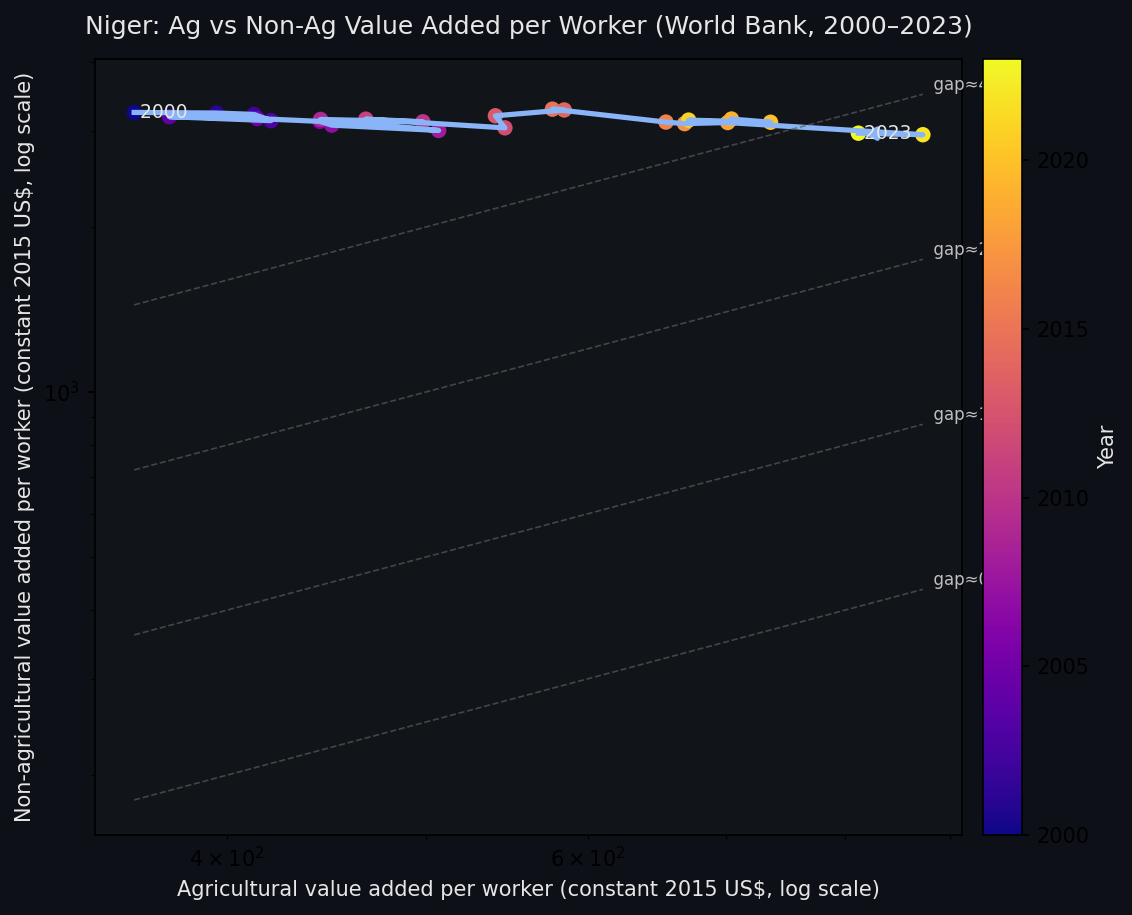

In [ ]:
# %pip install -q requests pandas numpy matplotlib

import time, requests, numpy as np, pandas as pd, matplotlib.pyplot as plt

ISO = "NER"         # Niger
START, END = 2000, 2023  # analysis window

# World Bank indicators
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",  # Ag value added (constant 2015 US$)
    "GDP_const":  "NY.GDP.MKTP.KD",  # GDP (constant 2015 US$)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",  # Labor force (active population)
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",  # Employment in agriculture (% of total employment)
}

def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value"])
    rows = [{"Year": int(d["date"]), "Value": d["value"]}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

# Pull series
agva  = wb_indicator(ISO, IND["AGVA_const"])
gdp   = wb_indicator(ISO, IND["GDP_const"])
lf    = wb_indicator(ISO, IND["LAB_FORCE"])
agemp = wb_indicator(ISO, IND["AG_EMP_PCT"])

if any(df.empty for df in [agva, gdp, lf, agemp]):
    raise RuntimeError("Missing series from World Bank for Niger; try rerunning or adjusting years.")

# Merge + compute per-worker series
df = (agva.rename(columns={"Value":"AgVA"})
          .merge(gdp.rename(columns={"Value":"GDP"}), on="Year", how="inner")
          .merge(lf.rename(columns={"Value":"LaborForce"}), on="Year", how="inner")
          .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on="Year", how="inner"))

# Basic filters
df = df[(df["Year"]>=START) & (df["Year"]<=END)]
df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]

# Workers & per-worker values
df["AgWorkers"]    = df["LaborForce"] * (df["AgEmpPct"]/100.0)
df["NonAgWorkers"] = df["LaborForce"] - df["AgWorkers"]
df = df[(df["AgWorkers"]>0) & (df["NonAgWorkers"]>0)]

df["AgPW"]    = df["AgVA"] / df["AgWorkers"]
df["NonAgPW"] = (df["GDP"] - df["AgVA"]) / df["NonAgWorkers"]
df = df[(df["AgPW"]>0) & (df["NonAgPW"]>0)].sort_values("Year")

if df.empty:
    raise RuntimeError("After filtering, no valid Niger observations remained.")

# Quick console summary (first/last years)
head = df.iloc[0]
tail = df.iloc[-1]
print("Niger — first & last points used")
print(pd.DataFrame({
    "Year": [int(head["Year"]), int(tail["Year"])],
    "Ag workers (M)": [head["AgWorkers"]/1e6, tail["AgWorkers"]/1e6],
    "Ag VA/worker (2015$)": [head["AgPW"], tail["AgPW"]],
    "Non-ag VA/worker (2015$)": [head["NonAgPW"], tail["NonAgPW"]],
}).round(3).to_string(index=False))

# Plot: log–log trajectory
plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})
fig, ax = plt.subplots(figsize=(7.8, 6.2), dpi=150)
ax.set_facecolor("#111418")

x = df["AgPW"].values
y = df["NonAgPW"].values
years = df["Year"].values

# line + points
ax.plot(x, y, lw=2.5, color="#8AB4F8")
sc = ax.scatter(x, y, c=years, s=55, cmap="plasma", edgecolor="none")

# arrow from penultimate to last point (if available)
if len(x) >= 2:
    ax.annotate("", xy=(x[-1], y[-1]), xytext=(x[-2], y[-2]),
                arrowprops=dict(arrowstyle="-|>", color="#8AB4F8", lw=2.2, mutation_scale=12))

# annotate start/end years
ax.text(x[0], y[0], f" {years[0]}", va="center", fontsize=9, color="#E6E6E6")
ax.text(x[-1], y[-1], f" {years[-1]}", va="center", fontsize=9, color="#E6E6E6")

# log scales
ax.set_xscale("log"); ax.set_yscale("log")

ax.set_xlabel("Agricultural value added per worker (constant 2015 US$, log scale)")
ax.set_ylabel("Non-agricultural value added per worker (constant 2015 US$, log scale)")
ax.set_title("Niger: Ag vs Non-Ag Value Added per Worker (World Bank, {}–{})".format(int(df["Year"].min()), int(df["Year"].max())),
             fontsize=12, pad=12)

# diagonal reference lines (iso-income lines)
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
for k in [0.5, 1, 2, 4]:
    # lines of constant nonag/ag per-worker ratio
    xx = np.linspace(xmin, xmax, 100)
    ax.plot(xx, k*xx, ls="--", lw=0.8, color="#5A5A5A", alpha=0.7)
    ax.text(xx[-1], k*xx[-1], f"  gap≈{k:.1f}×", color="#BFBFBF", fontsize=8, va="bottom")

# colorbar by year
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Year")

plt.tight_layout()
plt.show()


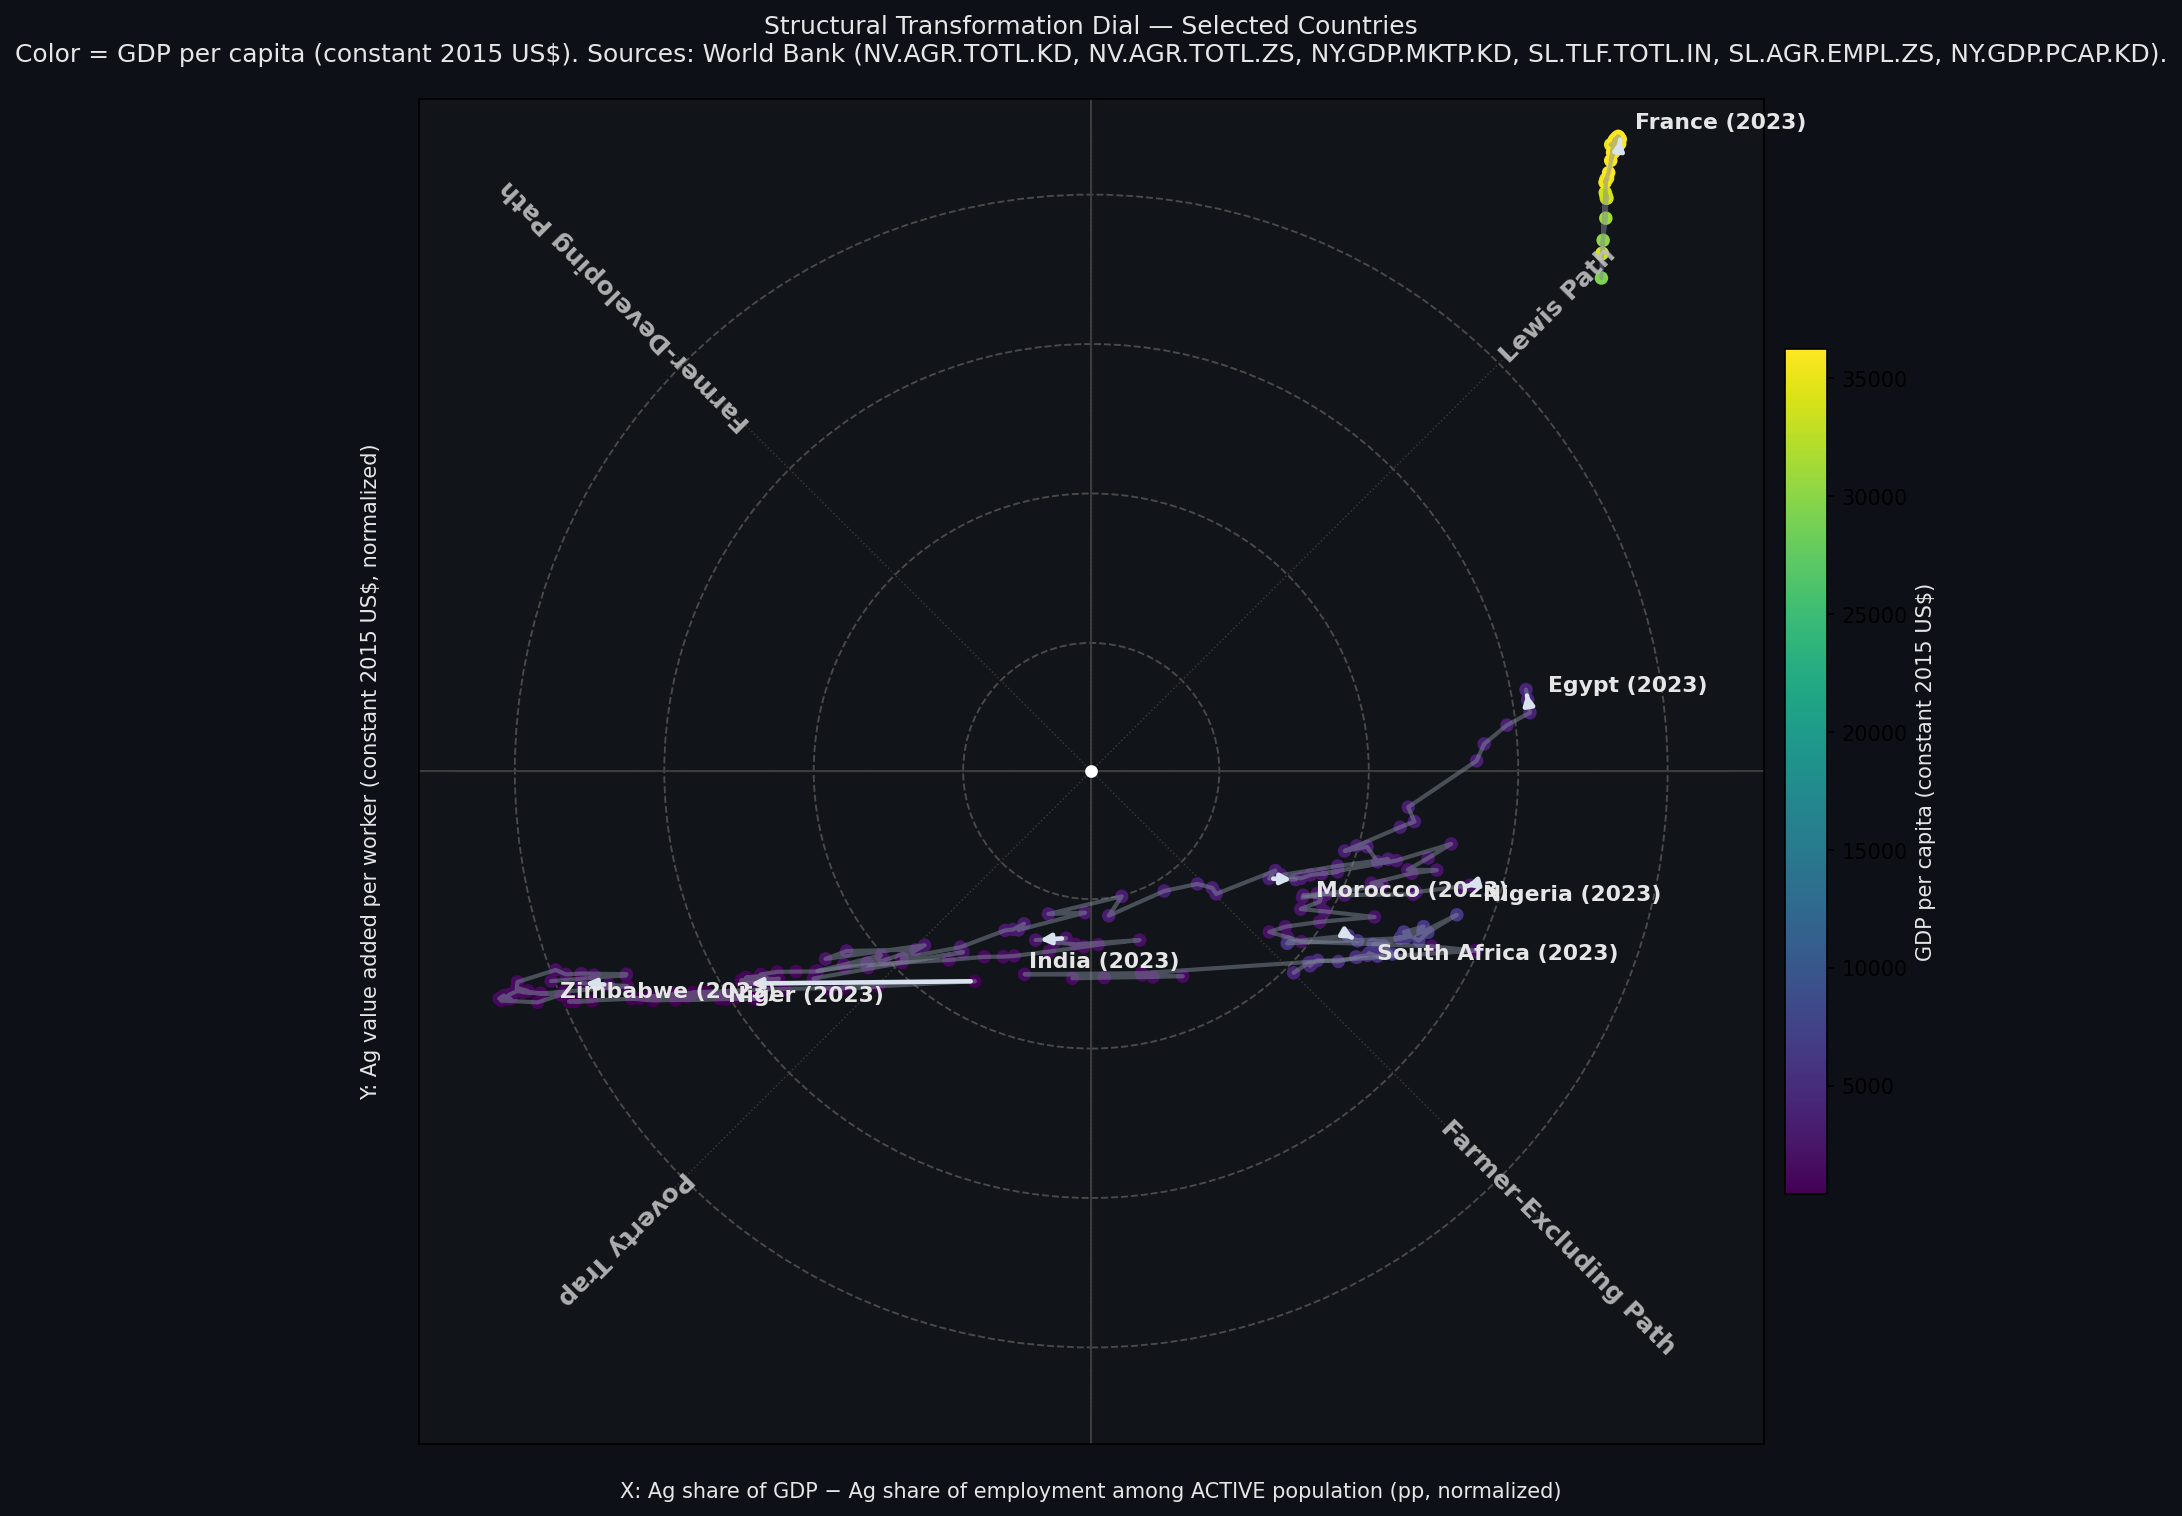

In [ ]:
# %pip install -q requests pandas numpy matplotlib

import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection

# ------------------ Parameters ------------------
START, END = 1995, 2023
MIN_YEARS = 10
COUNTRIES = {
    "Morocco": "MAR",
    "Egypt": "EGY",
    "Niger": "NER",
    "Nigeria": "NGA",
    "Zimbabwe": "ZWE",
    "South Africa": "ZAF",
    "India": "IND",
    "France": "FRA",
}

# World Bank indicators
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",   # Ag value added (const 2015 $)
    "AGVA_pct":   "NV.AGR.TOTL.ZS",   # Ag value added (% of GDP)
    "GDP_const":  "NY.GDP.MKTP.KD",   # GDP (const 2015 $)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",   # Labor force (active population)
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",   # Employment in agriculture (% of total employment)
    "GDPPC":      "NY.GDP.PCAP.KD",   # GDP per capita (const 2015 $) -> coloring
}

# ------------------ WB helpers ------------------
def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value"])
    rows = [{"Year": int(d["date"]), "Value": d["value"]}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

# ------------------ Build panel ------------------
series = {}
for name, iso in COUNTRIES.items():
    agva  = wb_indicator(iso, IND["AGVA_const"])
    gdp   = wb_indicator(iso, IND["GDP_const"])
    agpct = wb_indicator(iso, IND["AGVA_pct"])
    lf    = wb_indicator(iso, IND["LAB_FORCE"])
    agemp = wb_indicator(iso, IND["AG_EMP_PCT"])
    gdppc = wb_indicator(iso, IND["GDPPC"])
    if any(df.empty for df in [agva, gdp, agpct, lf, agemp, gdppc]):
        continue

    df = (agva.rename(columns={"Value":"AgVA"})
              .merge(gdp.rename(columns={"Value":"GDP"}), on="Year", how="inner")
              .merge(agpct.rename(columns={"Value":"AgGDPpct"}), on="Year", how="inner")
              .merge(lf.rename(columns={"Value":"LaborForce"}), on="Year", how="inner")
              .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on="Year", how="inner")
              .merge(gdppc.rename(columns={"Value":"GDPpc"}), on="Year", how="inner"))

    df = df[(df["Year"]>=START) & (df["Year"]<=END)]
    df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
    if df.empty:
        continue

    # Workers & axes
    df["AgWorkers"]   = df["LaborForce"] * (df["AgEmpPct"]/100.0)
    df = df[df["AgWorkers"]>0]
    if df.shape[0] < MIN_YEARS:
        continue

    df["AgEmp_share"] = (df["AgWorkers"]/df["LaborForce"])*100.0  # %
    df["AgGDP_share"] = df["AgGDPpct"]                            # %
    df["x_gap_pp"]    = df["AgGDP_share"] - df["AgEmp_share"]     # percentage points
    df["AgVA_per_worker"] = df["AgVA"] / df["AgWorkers"]

    df["Country"] = name
    series[name] = df.sort_values("Year").reset_index(drop=True)

if not series:
    raise RuntimeError("No valid data returned for the selected countries.")

# ------------------ Consistent display scaling ------------------
# We'll squash to [-1,1] using mean/std computed across all selected countries.
def squash_with_params(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

all_x = np.concatenate([s["x_gap_pp"].values for s in series.values()])
all_y = np.concatenate([s["AgVA_per_worker"].values for s in series.values()])
X_MEAN, X_STD = np.nanmean(all_x), np.nanstd(all_x)
Y_MEAN, Y_STD = np.nanmean(all_y), np.nanstd(all_y)

# ------------------ Plot ------------------
plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})

def draw_concentric(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)

fig = plt.figure(figsize=(10.8, 10.8), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")
draw_concentric(ax, radii=np.linspace(0.2,0.9,4))
ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

# Quadrant labels (visual heuristic)
for txt, deg in [
    ("Farmer-Developing Path", 135),
    ("Lewis Path",               45),
    ("Farmer-Excluding Path",  -45),
    ("Poverty Trap",           -135),
]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=12, rotation=deg, rotation_mode="anchor",
            color="#BFBFBF", weight="bold", alpha=0.9)

# Color normalization for GDP per capita
# We’ll map to a reasonable range for readability
all_gdppc = np.concatenate([s["GDPpc"].values for s in series.values()])
vmin = np.nanpercentile(all_gdppc, 5)
vmax = np.nanpercentile(all_gdppc, 95)

# Plot each country: neutral path + GDPpc-colored points + arrow & end label
for name, df in series.items():
    x = squash_with_params(df["x_gap_pp"].values, X_MEAN, X_STD)
    y = squash_with_params(df["AgVA_per_worker"].values, Y_MEAN, Y_STD)
    c = np.clip(df["GDPpc"].values, vmin, vmax)

    # neutral line under the colored points
    ax.plot(x, y, lw=2.0, color="#808A9B", alpha=0.5, solid_capstyle="round")
    # colored points by GDP per capita
    sc = ax.scatter(x, y, c=c, s=42, cmap="viridis", vmin=vmin, vmax=vmax, edgecolor="none")

    # arrow from penultimate to last
    if len(x) >= 2:
        ax.annotate("", xy=(x[-1],y[-1]), xytext=(x[-2],y[-2]),
                    arrowprops=dict(arrowstyle="-|>", color="#D9E3F0", lw=2.2, mutation_scale=10))
    # label near the last point
    theta = math.atan2(y[-1], x[-1]); off=0.035
    ax.text(x[-1]+off*math.cos(theta), y[-1]+off*math.sin(theta),
            f"{name} ({int(df['Year'].iloc[-1])})", color="#E6E6E6", fontsize=10.5, weight="bold", va="center")

# Origin + labels
ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("X: Ag share of GDP − Ag share of employment among ACTIVE population (pp, normalized)", labelpad=18)
ax.set_ylabel("Y: Ag value added per worker (constant 2015 US$, normalized)", labelpad=18)
ax.set_title(
    "Structural Transformation Dial — Selected Countries\n"
    "Color = GDP per capita (constant 2015 US$). Sources: World Bank (NV.AGR.TOTL.KD, NV.AGR.TOTL.ZS, "
    "NY.GDP.MKTP.KD, SL.TLF.TOTL.IN, SL.AGR.EMPL.ZS, NY.GDP.PCAP.KD).",
    fontsize=12, pad=18, color="#E6E6E6"
)

# One shared colorbar
cb = plt.colorbar(sc, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("GDP per capita (constant 2015 US$)")

plt.tight_layout()
plt.show()


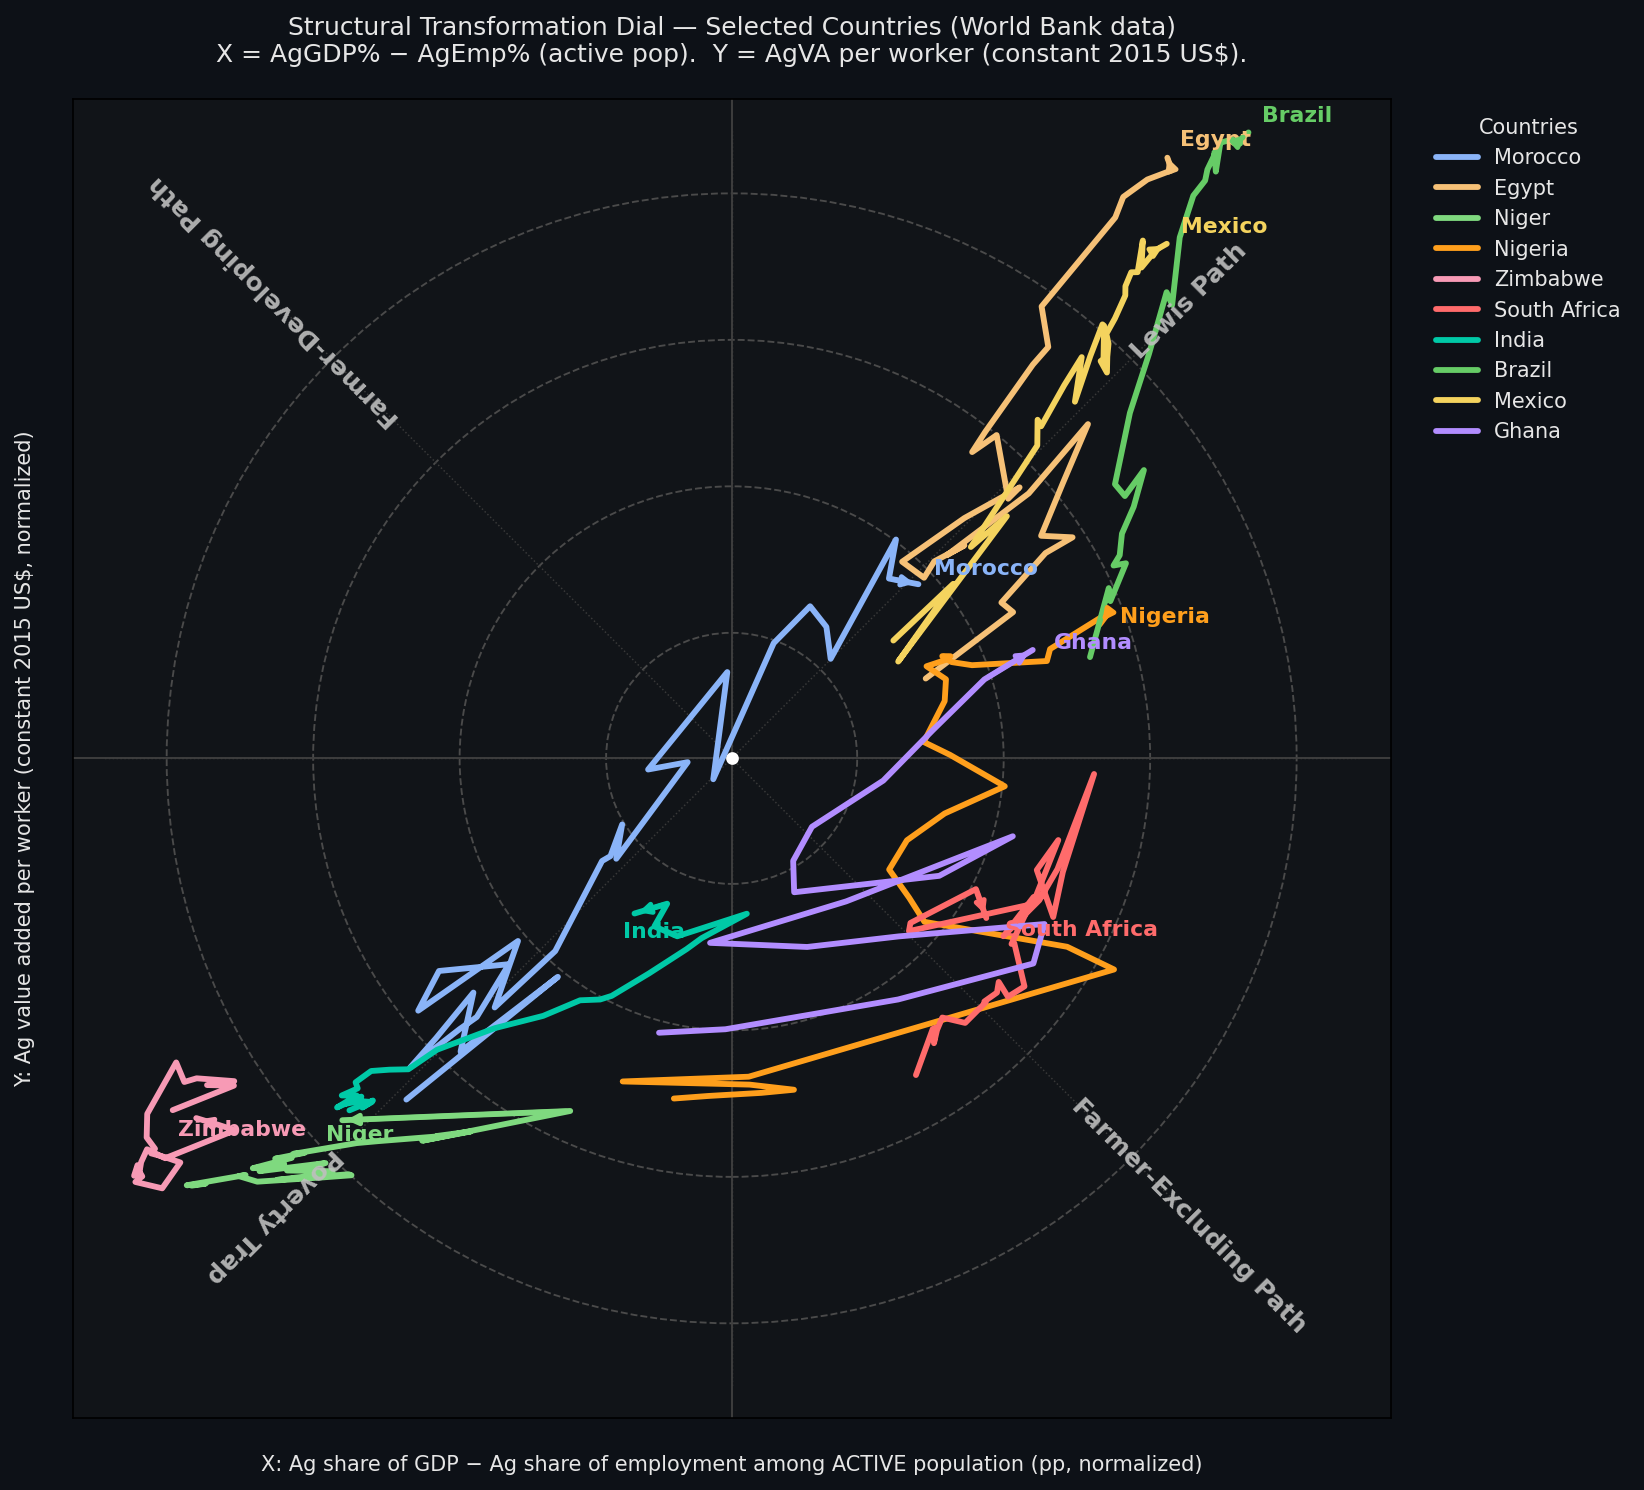

In [ ]:
# %pip install -q requests pandas numpy matplotlib

import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ------------------ Parameters ------------------
START, END = 1995, 2023
MIN_YEARS = 10

COUNTRIES = {
    "Morocco": "MAR",
    "Egypt": "EGY",        # kept
    "Niger": "NER",
    "Nigeria": "NGA",
    "Zimbabwe": "ZWE",
    "South Africa": "ZAF",
    "India": "IND",
    "Brazil": "BRA",
    # "Argentina": "ARG",  # removed
    "Mexico": "MEX",
    "Ghana": "GHA",
}

# Fixed colors per country (dark-friendly)
PALETTE = {
    "Morocco": "#8AB4F8",
    "Egypt": "#F6C177",
    "Niger": "#7FD97F",
    "Nigeria": "#FF9F1C",
    "Zimbabwe": "#F79AB5",
    "South Africa": "#FF6B6B",
    "India": "#00C9A7",
    "Brazil": "#66CC66",
    "Mexico": "#F4D35E",
    "Ghana": "#B28DFF",
}

# ------------------ World Bank indicators ------------------
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",   # Ag value added (constant 2015 US$)
    "AGVA_pct":   "NV.AGR.TOTL.ZS",   # Ag value added (% of GDP)
    "GDP_const":  "NY.GDP.MKTP.KD",   # GDP (constant 2015 US$)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",   # Labor force (active population)
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",   # Employment in agriculture (% of total employment)
}

def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value"])
    rows = [{"Year": int(d["date"]), "Value": d["value"]}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

# ------------------ Build series for each country ------------------
series = {}
for name, iso in COUNTRIES.items():
    agva  = wb_indicator(iso, IND["AGVA_const"])
    gdp   = wb_indicator(iso, IND["GDP_const"])
    agpct = wb_indicator(iso, IND["AGVA_pct"])
    lf    = wb_indicator(iso, IND["LAB_FORCE"])
    agemp = wb_indicator(iso, IND["AG_EMP_PCT"])
    if any(df.empty for df in [agva, gdp, agpct, lf, agemp]):
        continue

    df = (agva.rename(columns={"Value":"AgVA"})
              .merge(gdp.rename(columns={"Value":"GDP"}), on="Year", how="inner")
              .merge(agpct.rename(columns={"Value":"AgGDPpct"}), on="Year", how="inner")
              .merge(lf.rename(columns={"Value":"LaborForce"}), on="Year", how="inner")
              .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on="Year", how="inner"))

    # Keep clean years and positive magnitudes
    df = df[(df["Year"]>=START) & (df["Year"]<=END)]
    df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
    if df.empty:
        continue

    # Workers & axes
    df["AgWorkers"] = df["LaborForce"] * (df["AgEmpPct"]/100.0)
    df = df[df["AgWorkers"]>0]
    if df.shape[0] < MIN_YEARS:
        continue

    df["AgEmp_share"] = (df["AgWorkers"]/df["LaborForce"])*100.0  # %
    df["AgGDP_share"] = df["AgGDPpct"]                            # %
    df["x_gap_pp"]    = df["AgGDP_share"] - df["AgEmp_share"]     # percentage points
    df["AgVA_per_worker"] = df["AgVA"] / df["AgWorkers"]

    df["Country"] = name
    series[name] = df.sort_values("Year").reset_index(drop=True)

if not series:
    raise RuntimeError("No valid data returned for the selected countries.")

# ------------------ Consistent scaling within this plot ------------------
def squash_with_params(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

all_x = np.concatenate([s["x_gap_pp"].values for s in series.values()])
all_y = np.concatenate([s["AgVA_per_worker"].values for s in series.values()])
X_MEAN, X_STD = np.nanmean(all_x), np.nanstd(all_x)
Y_MEAN, Y_STD = np.nanmean(all_y), np.nanstd(all_y)

# ------------------ Plot ------------------
plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})

def draw_concentric(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)

fig = plt.figure(figsize=(11, 11), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")
draw_concentric(ax, radii=np.linspace(0.2,0.9,4))
ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

# Quadrant labels (visual heuristic)
for txt, deg in [
    ("Farmer-Developing Path", 135),
    ("Lewis Path",               45),
    ("Farmer-Excluding Path",  -45),
    ("Poverty Trap",           -135),
]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=12, rotation=deg, rotation_mode="anchor",
            color="#BFBFBF", weight="bold", alpha=0.9)

# Draw each country path in its own color
for name, df in series.items():
    x = squash_with_params(df["x_gap_pp"].values, X_MEAN, X_STD)
    y = squash_with_params(df["AgVA_per_worker"].values, Y_MEAN, Y_STD)
    col = PALETTE.get(name, "#E0E0E0")
    ax.plot(x, y, lw=2.8, color=col, solid_capstyle="round", label=name)
    if len(x) >= 2:
        ax.annotate("", xy=(x[-1],y[-1]), xytext=(x[-2],y[-2]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.4, mutation_scale=10))
    # end label near the arrow
    theta = math.atan2(y[-1], x[-1]); off=0.035
    ax.text(x[-1]+off*math.cos(theta), y[-1]+off*math.sin(theta),
            f"{name}", color=col, fontsize=10.5, weight="bold", va="center")

# Origin + labels
ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("X: Ag share of GDP − Ag share of employment among ACTIVE population (pp, normalized)", labelpad=18)
ax.set_ylabel("Y: Ag value added per worker (constant 2015 US$, normalized)", labelpad=18)
ax.set_title(
    "Structural Transformation Dial — Selected Countries (World Bank data)\n"
    "X = AgGDP% − AgEmp% (active pop).  Y = AgVA per worker (constant 2015 US$).",
    fontsize=12, pad=18, color="#E6E6E6"
)

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Countries")
plt.tight_layout()
plt.show()


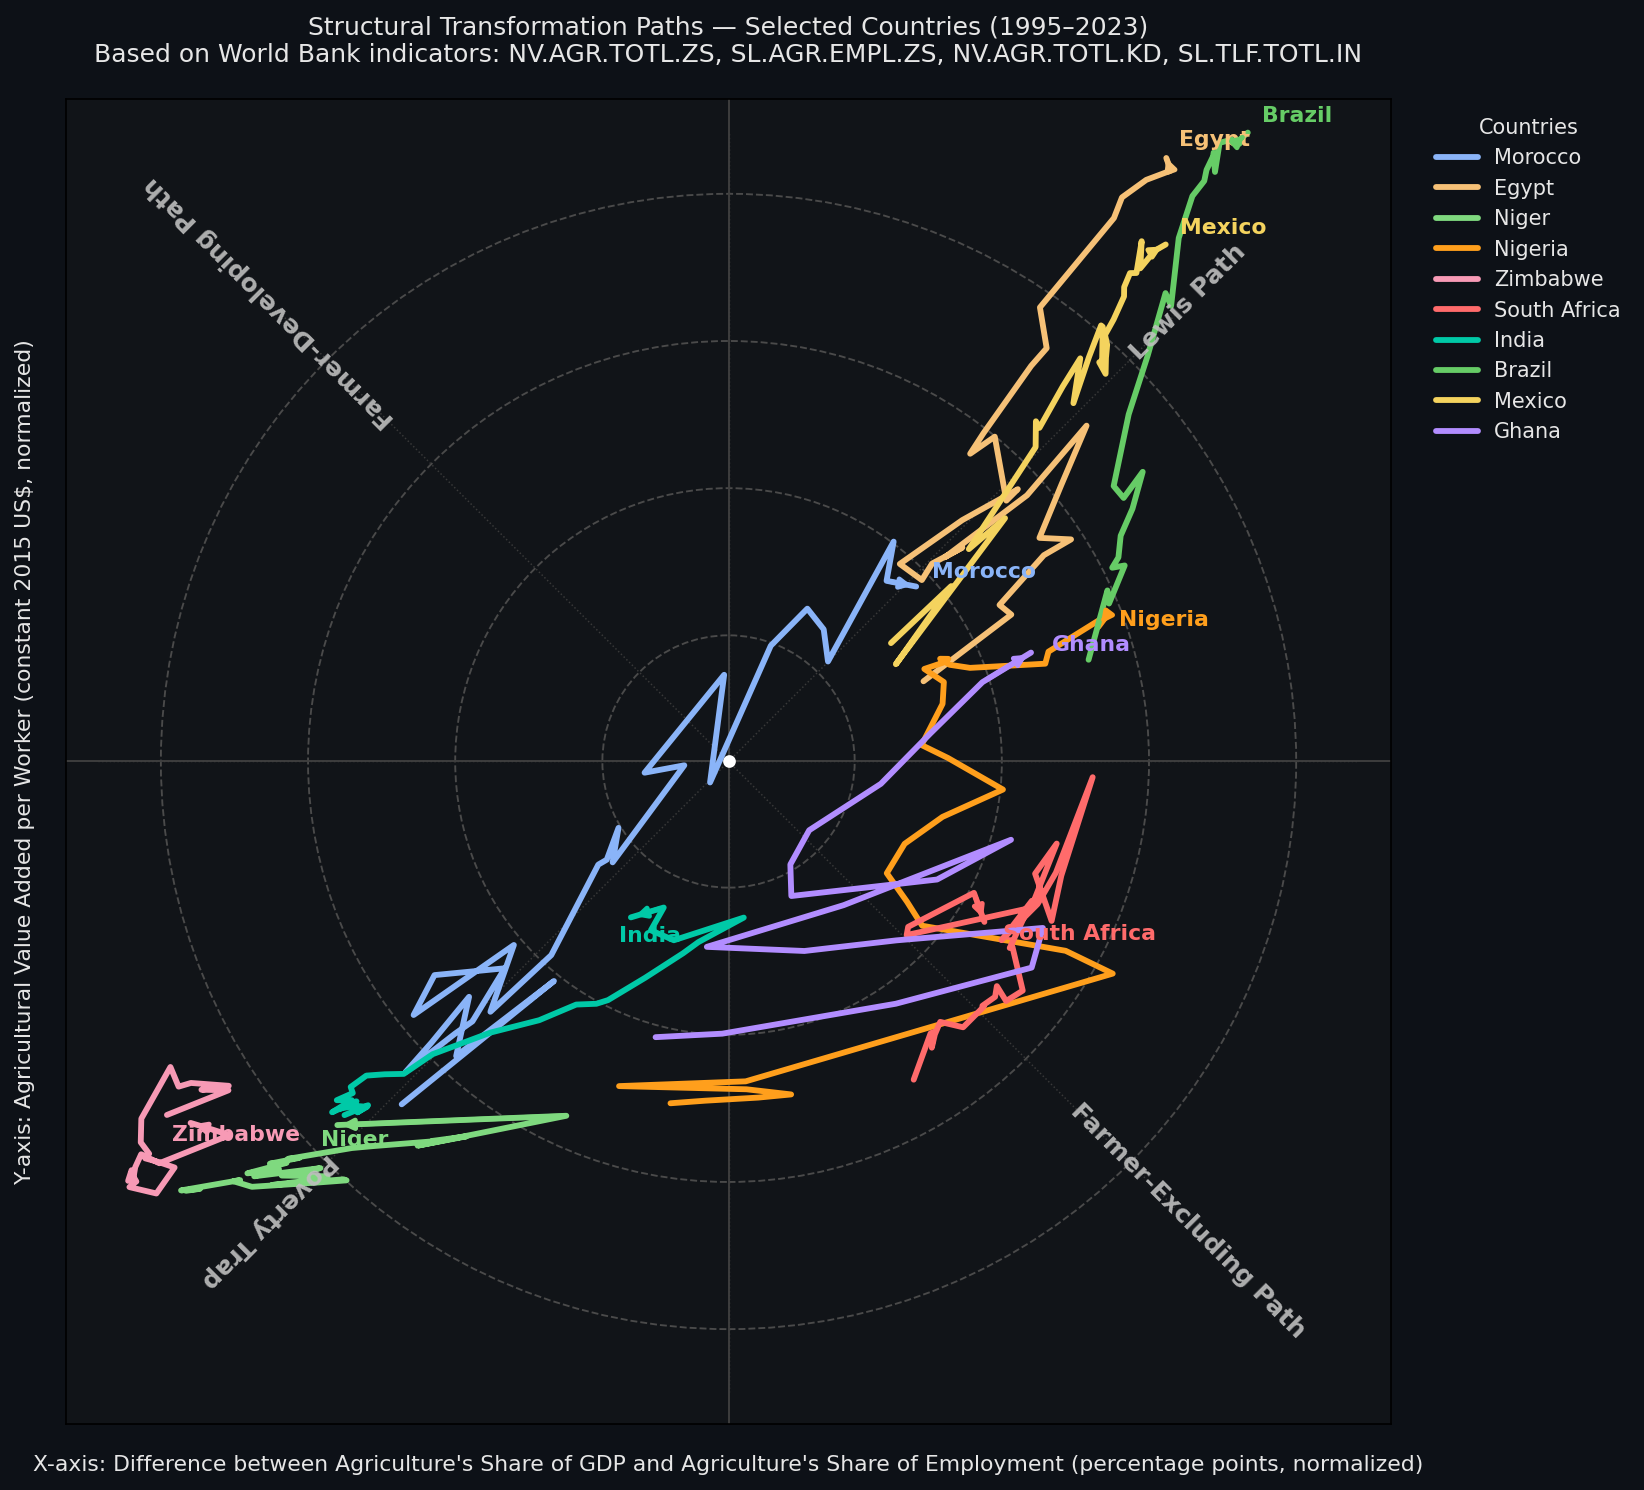

In [ ]:
# %pip install -q requests pandas numpy matplotlib

import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ------------------ Parameters ------------------
START, END = 1995, 2023
MIN_YEARS = 10

COUNTRIES = {
    "Morocco": "MAR",
    "Egypt": "EGY",
    "Niger": "NER",
    "Nigeria": "NGA",
    "Zimbabwe": "ZWE",
    "South Africa": "ZAF",
    "India": "IND",
    "Brazil": "BRA",
    "Mexico": "MEX",
    "Ghana": "GHA",
}

PALETTE = {
    "Morocco": "#8AB4F8",
    "Egypt": "#F6C177",
    "Niger": "#7FD97F",
    "Nigeria": "#FF9F1C",
    "Zimbabwe": "#F79AB5",
    "South Africa": "#FF6B6B",
    "India": "#00C9A7",
    "Brazil": "#66CC66",
    "Mexico": "#F4D35E",
    "Ghana": "#B28DFF",
}

# ------------------ World Bank indicators ------------------
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",   # Ag value added (constant 2015 US$)
    "AGVA_pct":   "NV.AGR.TOTL.ZS",   # Ag value added (% of GDP)
    "GDP_const":  "NY.GDP.MKTP.KD",   # GDP (constant 2015 US$)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",   # Labor force (active population)
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",   # Employment in agriculture (% of total employment)
}

def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value"])
    rows = [{"Year": int(d["date"]), "Value": d["value"]}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

# ------------------ Build series for each country ------------------
series = {}
for name, iso in COUNTRIES.items():
    agva  = wb_indicator(iso, IND["AGVA_const"])
    gdp   = wb_indicator(iso, IND["GDP_const"])
    agpct = wb_indicator(iso, IND["AGVA_pct"])
    lf    = wb_indicator(iso, IND["LAB_FORCE"])
    agemp = wb_indicator(iso, IND["AG_EMP_PCT"])
    if any(df.empty for df in [agva, gdp, agpct, lf, agemp]):
        continue

    df = (agva.rename(columns={"Value":"AgVA"})
              .merge(gdp.rename(columns={"Value":"GDP"}), on="Year", how="inner")
              .merge(agpct.rename(columns={"Value":"AgGDPpct"}), on="Year", how="inner")
              .merge(lf.rename(columns={"Value":"LaborForce"}), on="Year", how="inner")
              .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on="Year", how="inner"))

    df = df[(df["Year"]>=START) & (df["Year"]<=END)]
    df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
    if df.empty: continue

    df["AgWorkers"] = df["LaborForce"] * (df["AgEmpPct"]/100.0)
    df = df[df["AgWorkers"]>0]
    if df.shape[0] < MIN_YEARS: continue

    df["AgEmp_share"] = (df["AgWorkers"]/df["LaborForce"])*100.0
    df["AgGDP_share"] = df["AgGDPpct"]
    df["x_gap_pp"]    = df["AgGDP_share"] - df["AgEmp_share"]
    df["AgVA_per_worker"] = df["AgVA"] / df["AgWorkers"]

    df["Country"] = name
    series[name] = df.sort_values("Year").reset_index(drop=True)

# ------------------ Consistent scaling ------------------
def squash(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

all_x = np.concatenate([s["x_gap_pp"].values for s in series.values()])
all_y = np.concatenate([s["AgVA_per_worker"].values for s in series.values()])
X_MEAN, X_STD = np.nanmean(all_x), np.nanstd(all_x)
Y_MEAN, Y_STD = np.nanmean(all_y), np.nanstd(all_y)

# ------------------ Plot ------------------
plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})

def draw_concentric(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)

fig = plt.figure(figsize=(11, 11), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")
draw_concentric(ax, radii=np.linspace(0.2,0.9,4))
ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

# Quadrant labels
for txt, deg in [
    ("Farmer-Developing Path", 135),
    ("Lewis Path",               45),
    ("Farmer-Excluding Path",  -45),
    ("Poverty Trap",           -135),
]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=12, rotation=deg, rotation_mode="anchor",
            color="#BFBFBF", weight="bold", alpha=0.9)

# Country paths
for name, df in series.items():
    x = squash(df["x_gap_pp"].values, X_MEAN, X_STD)
    y = squash(df["AgVA_per_worker"].values, Y_MEAN, Y_STD)
    col = PALETTE.get(name, "#E0E0E0")
    ax.plot(x, y, lw=2.8, color=col, solid_capstyle="round", label=name)
    if len(x) >= 2:
        ax.annotate("", xy=(x[-1],y[-1]), xytext=(x[-2],y[-2]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.4, mutation_scale=10))
    theta = math.atan2(y[-1], x[-1]); off=0.035
    ax.text(x[-1]+off*math.cos(theta), y[-1]+off*math.sin(theta),
            f"{name}", color=col, fontsize=10.5, weight="bold", va="center")

# Axis labels and title
ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])

ax.set_xlabel(
    "X-axis: Difference between Agriculture's Share of GDP and Agriculture's Share of Employment (percentage points, normalized)",
    labelpad=15, fontsize=10.5
)
ax.set_ylabel(
    "Y-axis: Agricultural Value Added per Worker (constant 2015 US$, normalized)",
    labelpad=15, fontsize=10.5
)

ax.set_title(
    "Structural Transformation Paths — Selected Countries (1995–2023)\n"
    "Based on World Bank indicators: NV.AGR.TOTL.ZS, SL.AGR.EMPL.ZS, NV.AGR.TOTL.KD, SL.TLF.TOTL.IN",
    fontsize=12, pad=18, color="#E6E6E6"
)

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Countries")
plt.tight_layout()
plt.show()


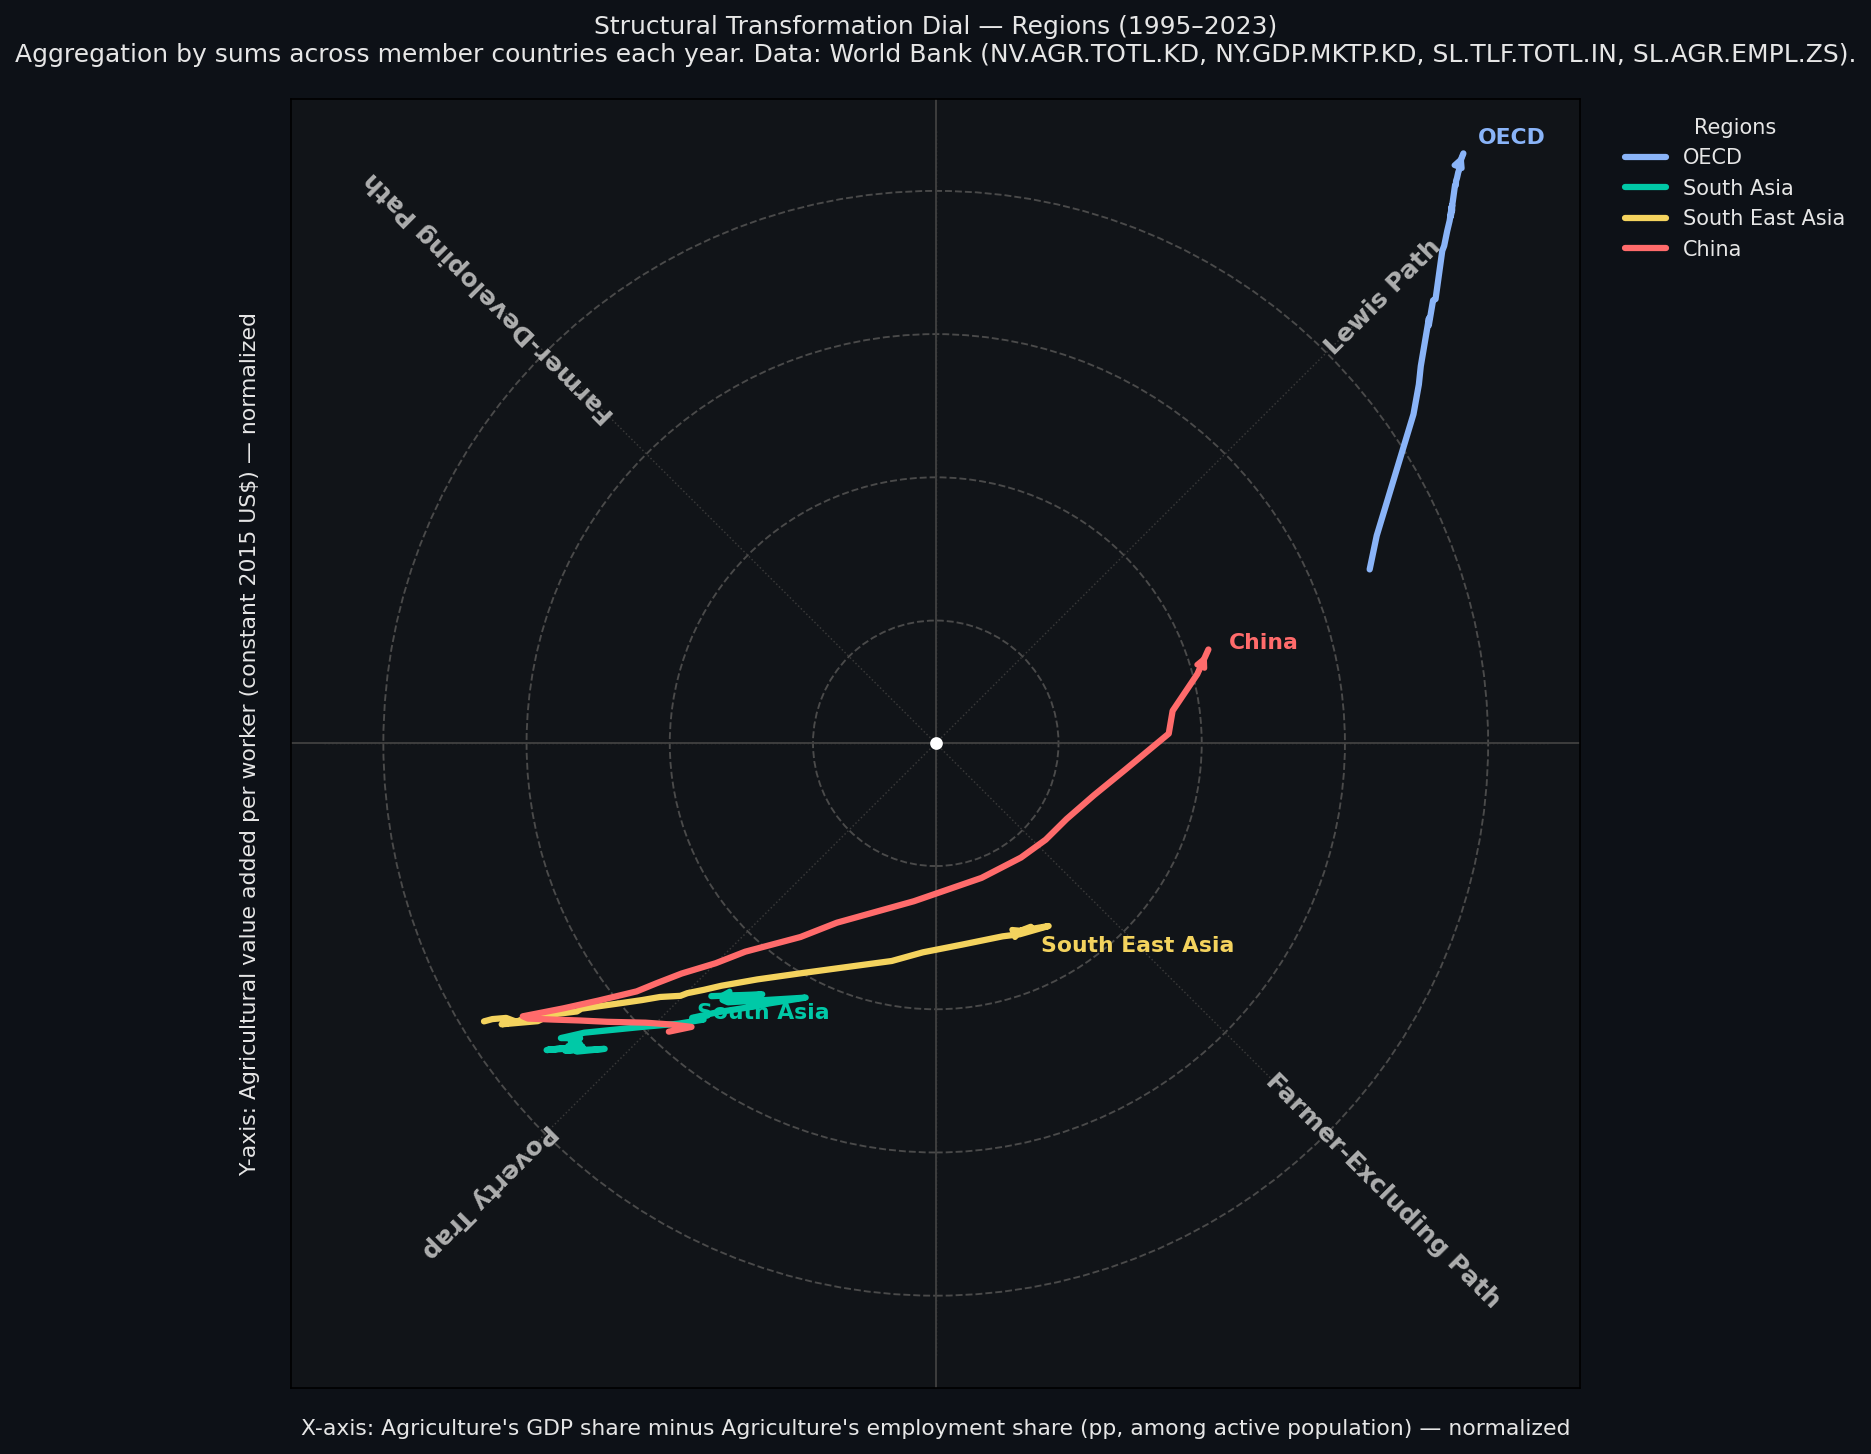

         Region  Years covered     Range
           OECD             29 1995-2023
           MENA              0         -
     South Asia             29 1995-2023
South East Asia             29 1995-2023
          China             29 1995-2023


In [ ]:
# %pip install -q requests pandas numpy matplotlib

import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ------------------ Parameters ------------------
START, END = 1995, 2023
MIN_YEARS = 10

# ------------------ Region definitions ------------------
# World Bank "regions" for MENA and South Asia will be auto-detected via API metadata.
# South East Asia = ASEAN (+ Timor-Leste) by ISO3 list.
SEA_ISO3 = {
    "BRN","KHM","IDN","LAO","MYS","MMR","PHL","SGP","THA","VNM","TLS"
}

# OECD members (ISO3), static list (38 as of 2024/25)
OECD_ISO3 = {
    "AUS","AUT","BEL","CAN","CHL","COL","CRI","CZE","DNK","EST","FIN","FRA","DEU","GRC","HUN","ISL",
    "IRL","ISR","ITA","JPN","KOR","LVA","LTU","LUX","MEX","NLD","NZL","NOR","POL","PRT","SVK","SVN",
    "ESP","SWE","CHE","TUR","GBR","USA"
}

# China as its own "region"
REGIONS = {
    "OECD": {"mode":"list", "iso3": OECD_ISO3},
    "MENA": {"mode":"wb_region", "wb_value":"Middle East & North Africa"},
    "South Asia": {"mode":"wb_region", "wb_value":"South Asia"},
    "South East Asia": {"mode":"list", "iso3": SEA_ISO3},
    "China": {"mode":"list", "iso3": {"CHN"}},
}

# Region colors
PALETTE = {
    "OECD": "#8AB4F8",
    "MENA": "#F6C177",
    "South Asia": "#00C9A7",
    "South East Asia": "#F4D35E",
    "China": "#FF6B6B",
}

# ------------------ World Bank indicators ------------------
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",   # Ag value added (constant 2015 US$)
    "AGVA_pct":   "NV.AGR.TOTL.ZS",   # Ag value added (% of GDP) [not used directly in aggregation]
    "GDP_const":  "NY.GDP.MKTP.KD",   # GDP (constant 2015 US$)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",   # Labor force (active population)
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",   # Employment in agriculture (% of total employment)
}

def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value","iso3"])
    rows = [{"Year": int(d["date"]), "Value": d["value"], "iso3": iso3}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

def wb_countries_world():
    url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
    js = wb_get(url)
    rows = []
    for d in js[1]:
        # drop aggregates (region id "NA" or id length != 3)
        if d.get("region", {}).get("id") == "NA":
            continue
        if len(d["id"]) != 3:
            continue
        rows.append({
            "iso3": d["id"],
            "name": d["name"],
            "region_value": d.get("region",{}).get("value",""),
        })
    return pd.DataFrame(rows)

# ------------------ Region membership resolution ------------------
meta_countries = wb_countries_world()
ISO_BY_REGION = {}

for rname, spec in REGIONS.items():
    if spec["mode"] == "list":
        ISO_BY_REGION[rname] = sorted(list(spec["iso3"]))
    elif spec["mode"] == "wb_region":
        iso = meta_countries.loc[
            meta_countries["region_value"] == spec["wb_value"], "iso3"
        ].tolist()
        ISO_BY_REGION[rname] = sorted(iso)
    else:
        ISO_BY_REGION[rname] = []

# ------------------ Pull & aggregate per region ------------------
# Approach: For each region and year, sum GDP, AgVA, LaborForce, AgWorkers; then compute:
# AgEmp_share = (AgWorkers/LaborForce)*100, AgGDP_share = (AgVA/GDP)*100
# X = AgGDP_share - AgEmp_share; Y = AgVA_per_worker = AgVA/AgWorkers

def region_timeseries(region_iso3_list):
    # pull all indicators for all iso3 codes, then merge & aggregate
    frames = []
    for iso in region_iso3_list:
        agva  = wb_indicator(iso, IND["AGVA_const"])
        gdp   = wb_indicator(iso, IND["GDP_const"])
        lf    = wb_indicator(iso, IND["LAB_FORCE"])
        agemp = wb_indicator(iso, IND["AG_EMP_PCT"])
        if any(df.empty for df in [agva, gdp, lf, agemp]):
            continue
        df = (agva.rename(columns={"Value":"AgVA"})
                .merge(gdp.rename(columns={"Value":"GDP"}), on=["iso3","Year"], how="inner")
                .merge(lf.rename(columns={"Value":"LaborForce"}), on=["iso3","Year"], how="inner")
                .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on=["iso3","Year"], how="inner"))
        df = df[(df["Year"]>=START) & (df["Year"]<=END)]
        df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
        if df.empty:
            continue
        df["AgWorkers"] = df["LaborForce"] * (df["AgEmpPct"]/100.0)
        df = df[df["AgWorkers"]>0]
        if df.empty:
            continue
        frames.append(df[["Year","GDP","AgVA","LaborForce","AgWorkers"]])
    if not frames:
        return pd.DataFrame()
    panel = pd.concat(frames, ignore_index=True)
    agg = (panel.groupby("Year", as_index=False)
                .agg({"GDP":"sum","AgVA":"sum","LaborForce":"sum","AgWorkers":"sum"}))
    # sanity
    agg = agg[(agg["GDP"]>0) & (agg["AgVA"]>0) & (agg["LaborForce"]>0) & (agg["AgWorkers"]>0)]
    if agg.shape[0] < MIN_YEARS:
        return pd.DataFrame()
    agg["AgEmp_share"] = (agg["AgWorkers"]/agg["LaborForce"])*100.0
    agg["AgGDP_share"] = (agg["AgVA"]/agg["GDP"])*100.0
    agg["x_gap_pp"]    = agg["AgGDP_share"] - agg["AgEmp_share"]
    agg["AgVA_per_worker"] = agg["AgVA"]/agg["AgWorkers"]
    return agg.sort_values("Year").reset_index(drop=True)

region_series = {}
for rname, iso_list in ISO_BY_REGION.items():
    s = region_timeseries(iso_list)
    if not s.empty:
        region_series[rname] = s

if not region_series:
    raise RuntimeError("No valid region series found. Check network or change years.")

# ------------------ Consistent display scaling across regions ------------------
def squash(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

all_x = np.concatenate([s["x_gap_pp"].values for s in region_series.values()])
all_y = np.concatenate([s["AgVA_per_worker"].values for s in region_series.values()])
X_MEAN, X_STD = np.nanmean(all_x), np.nanstd(all_x)
Y_MEAN, Y_STD = np.nanmean(all_y), np.nanstd(all_y)

# ------------------ Plot ------------------
plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})

def draw_concentric(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)

fig = plt.figure(figsize=(11, 11), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")
draw_concentric(ax, radii=np.linspace(0.2,0.9,4))
ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

# Quadrant labels (heuristic)
for txt, deg in [
    ("Farmer-Developing Path", 135),
    ("Lewis Path",               45),
    ("Farmer-Excluding Path",  -45),
    ("Poverty Trap",           -135),
]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=12, rotation=deg, rotation_mode="anchor",
            color="#BFBFBF", weight="bold", alpha=0.9)

# Plot each region
for rname, s in region_series.items():
    x = squash(s["x_gap_pp"].values, X_MEAN, X_STD)
    y = squash(s["AgVA_per_worker"].values, Y_MEAN, Y_STD)
    col = PALETTE.get(rname, "#E0E0E0")
    ax.plot(x, y, lw=3.0, color=col, solid_capstyle="round", label=rname)
    if len(x) >= 2:
        ax.annotate("", xy=(x[-1],y[-1]), xytext=(x[-2],y[-2]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.6, mutation_scale=10))
    # end label
    theta = math.atan2(y[-1], x[-1]); off=0.035
    ax.text(x[-1]+off*math.cos(theta), y[-1]+off*math.sin(theta),
            rname, color=col, fontsize=10.5, weight="bold", va="center")

# Labels & title
ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(
    "X-axis: Agriculture's GDP share minus Agriculture's employment share (pp, among active population) — normalized",
    labelpad=15, fontsize=10.5
)
ax.set_ylabel(
    "Y-axis: Agricultural value added per worker (constant 2015 US$) — normalized",
    labelpad=15, fontsize=10.5
)
ax.set_title(
    "Structural Transformation Dial — Regions (1995–2023)\n"
    "Aggregation by sums across member countries each year. Data: World Bank (NV.AGR.TOTL.KD, NY.GDP.MKTP.KD, SL.TLF.TOTL.IN, SL.AGR.EMPL.ZS).",
    fontsize=12, pad=18, color="#E6E6E6"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Regions")
plt.tight_layout()
plt.show()

# Optional: quick coverage table
cov = []
for rname, iso_list in ISO_BY_REGION.items():
    if rname not in region_series:
        cov.append([rname, 0, "-"])
    else:
        s = region_series[rname]
        cov.append([rname, s["Year"].nunique(), f"{int(s['Year'].min())}-{int(s['Year'].max())}"])
print(pd.DataFrame(cov, columns=["Region","Years covered","Range"]).to_string(index=False))


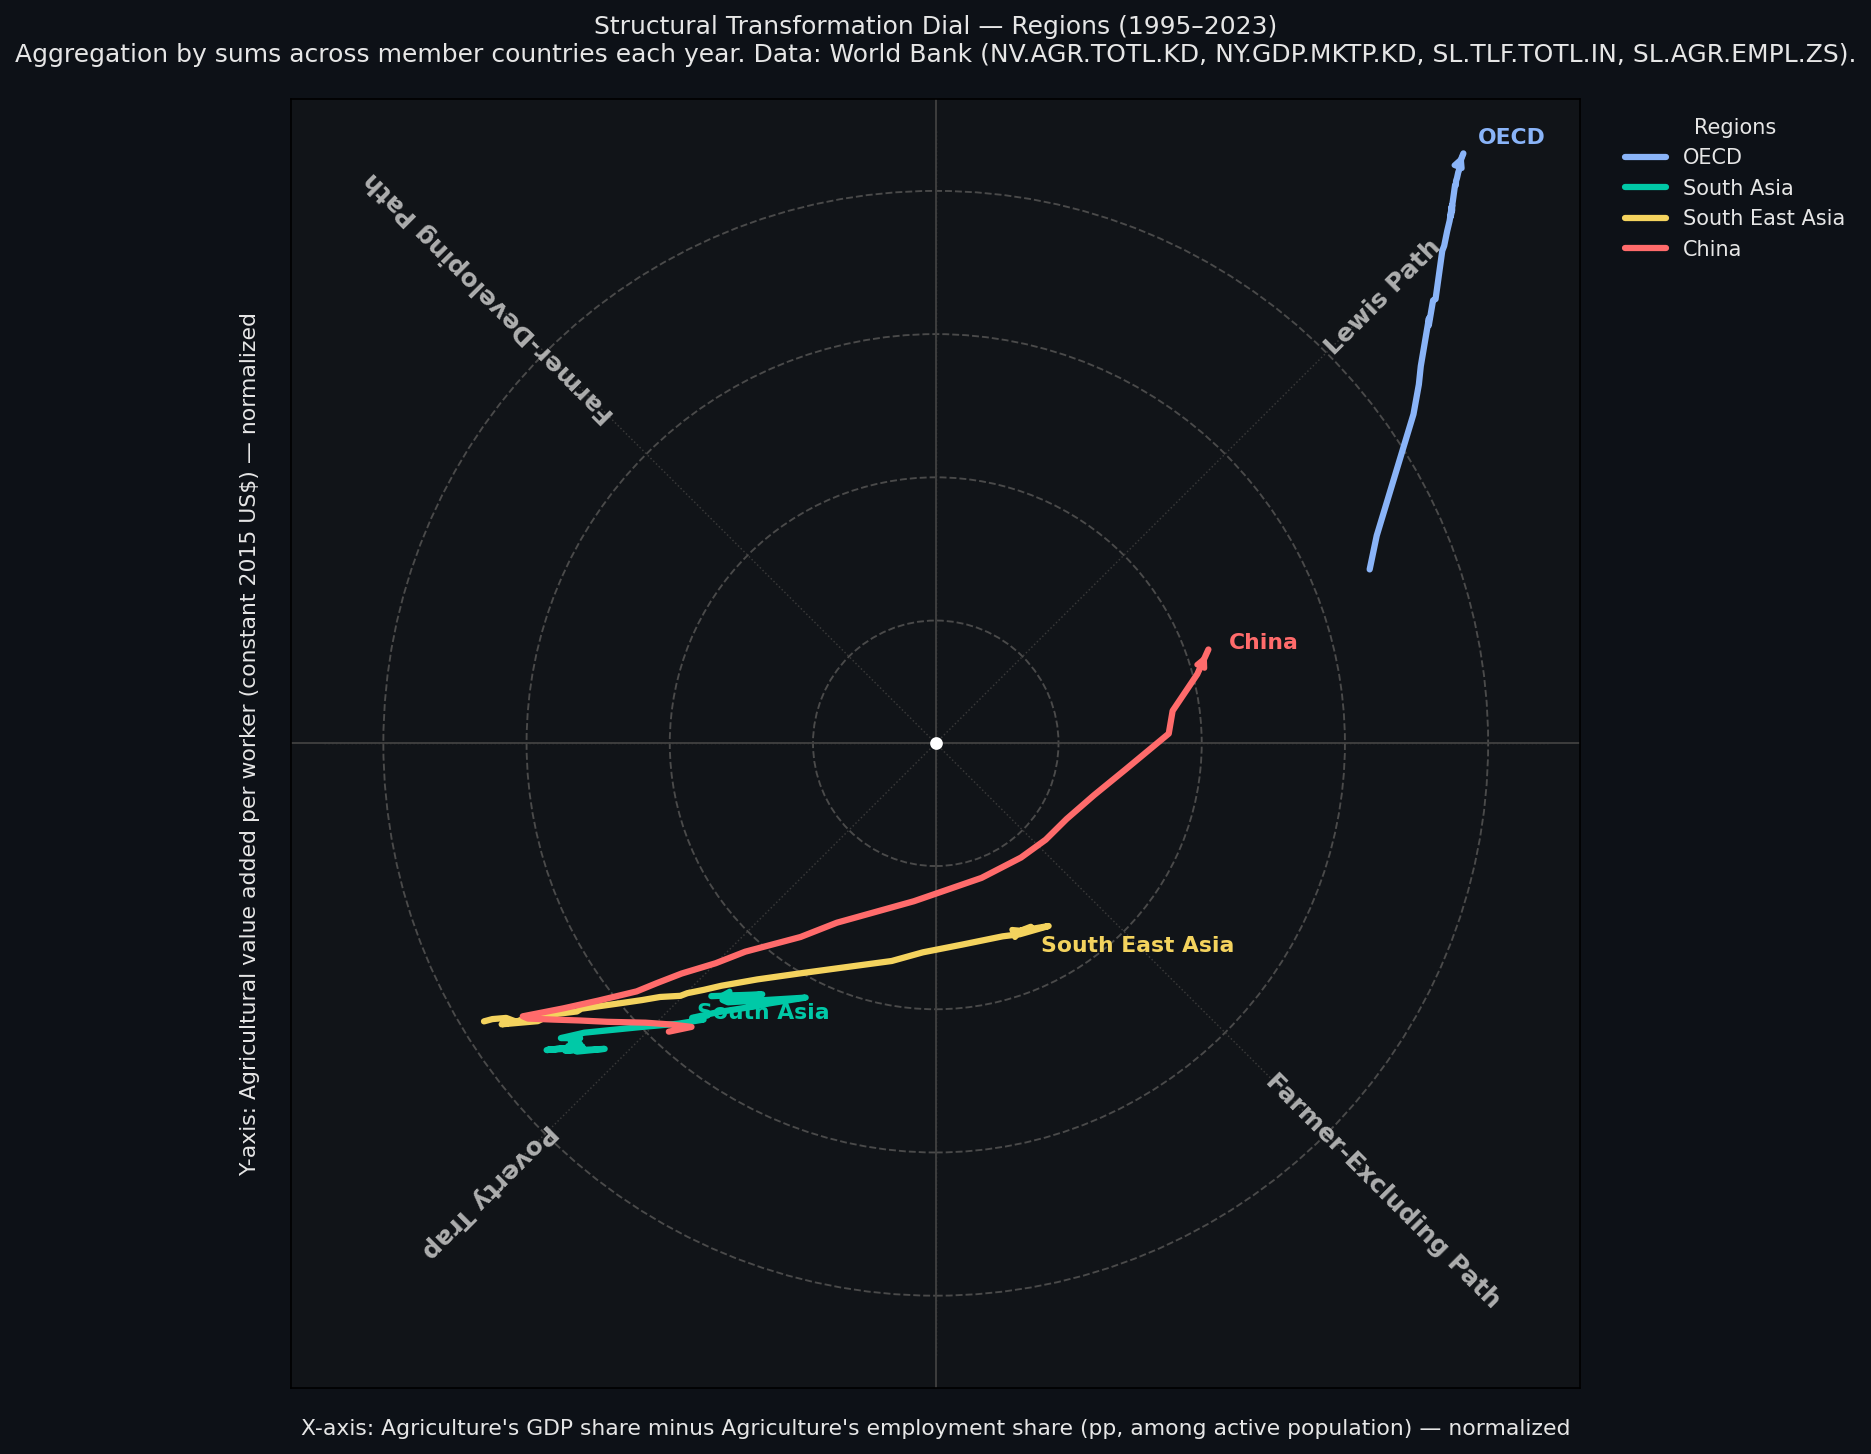

            Region  Years covered     Range
              OECD             29 1995-2023
              MENA              0         -
        South Asia             29 1995-2023
   South East Asia             29 1995-2023
             China             29 1995-2023
Sub-Saharan Africa              0         -


In [ ]:
# %pip install -q requests pandas numpy matplotlib

import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ------------------ Parameters ------------------
START, END = 1995, 2023
MIN_YEARS = 10

# ------------------ Region definitions ------------------
# South East Asia = ASEAN (+ Timor-Leste)
SEA_ISO3 = {
    "BRN","KHM","IDN","LAO","MYS","MMR","PHL","SGP","THA","VNM","TLS"
}

# OECD members (ISO3)
OECD_ISO3 = {
    "AUS","AUT","BEL","CAN","CHL","COL","CRI","CZE","DNK","EST","FIN","FRA","DEU","GRC","HUN","ISL",
    "IRL","ISR","ITA","JPN","KOR","LVA","LTU","LUX","MEX","NLD","NZL","NOR","POL","PRT","SVK","SVN",
    "ESP","SWE","CHE","TUR","GBR","USA"
}

# Regions to plot (now includes SSA)
REGIONS = {
    "OECD": {"mode":"list", "iso3": OECD_ISO3},
    "MENA": {"mode":"wb_region", "wb_value":"Middle East & North Africa"},
    "South Asia": {"mode":"wb_region", "wb_value":"South Asia"},
    "South East Asia": {"mode":"list", "iso3": SEA_ISO3},
    "China": {"mode":"list", "iso3": {"CHN"}},
    "Sub-Saharan Africa": {"mode":"wb_region", "wb_value":"Sub-Saharan Africa"},
}

# Region colors (dark-friendly)
PALETTE = {
    "OECD": "#8AB4F8",
    "MENA": "#F6C177",
    "South Asia": "#00C9A7",
    "South East Asia": "#F4D35E",
    "China": "#FF6B6B",
    "Sub-Saharan Africa": "#B28DFF",
}

# ------------------ World Bank indicators ------------------
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",   # Ag value added (constant 2015 US$)
    "GDP_const":  "NY.GDP.MKTP.KD",   # GDP (constant 2015 US$)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",   # Labor force (active population)
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",   # Employment in agriculture (% of total employment)
}

def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value","iso3"])
    rows = [{"Year": int(d["date"]), "Value": d["value"], "iso3": iso3}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

def wb_countries_world():
    url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
    js = wb_get(url)
    rows = []
    for d in js[1]:
        # drop aggregates (region id "NA" or id length != 3)
        if d.get("region", {}).get("id") == "NA":
            continue
        if len(d["id"]) != 3:
            continue
        rows.append({
            "iso3": d["id"],
            "name": d["name"],
            "region_value": d.get("region",{}).get("value",""),
        })
    return pd.DataFrame(rows)

# ------------------ Region membership resolution ------------------
meta_countries = wb_countries_world()
ISO_BY_REGION = {}
for rname, spec in REGIONS.items():
    if spec["mode"] == "list":
        ISO_BY_REGION[rname] = sorted(list(spec["iso3"]))
    elif spec["mode"] == "wb_region":
        iso = meta_countries.loc[
            meta_countries["region_value"] == spec["wb_value"], "iso3"
        ].tolist()
        ISO_BY_REGION[rname] = sorted(iso)
    else:
        ISO_BY_REGION[rname] = []

# ------------------ Pull & aggregate per region ------------------
# For each region-year: sum GDP, AgVA, LaborForce, AgWorkers; then compute shares and per-worker VA.
def region_timeseries(region_iso3_list):
    frames = []
    for iso in region_iso3_list:
        agva  = wb_indicator(iso, IND["AGVA_const"])
        gdp   = wb_indicator(iso, IND["GDP_const"])
        lf    = wb_indicator(iso, IND["LAB_FORCE"])
        agemp = wb_indicator(iso, IND["AG_EMP_PCT"])
        if any(df.empty for df in [agva, gdp, lf, agemp]):
            continue
        df = (agva.rename(columns={"Value":"AgVA"})
                .merge(gdp.rename(columns={"Value":"GDP"}), on=["iso3","Year"], how="inner")
                .merge(lf.rename(columns={"Value":"LaborForce"}), on=["iso3","Year"], how="inner")
                .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on=["iso3","Year"], how="inner"))
        df = df[(df["Year"]>=START) & (df["Year"]<=END)]
        df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
        if df.empty:
            continue
        df["AgWorkers"] = df["LaborForce"] * (df["AgEmpPct"]/100.0)
        df = df[df["AgWorkers"]>0]
        if df.empty:
            continue
        frames.append(df[["Year","GDP","AgVA","LaborForce","AgWorkers"]])
    if not frames:
        return pd.DataFrame()
    panel = pd.concat(frames, ignore_index=True)
    agg = (panel.groupby("Year", as_index=False)
                .agg({"GDP":"sum","AgVA":"sum","LaborForce":"sum","AgWorkers":"sum"}))
    agg = agg[(agg["GDP"]>0) & (agg["AgVA"]>0) & (agg["LaborForce"]>0) & (agg["AgWorkers"]>0)]
    if agg.shape[0] < MIN_YEARS:
        return pd.DataFrame()
    agg["AgEmp_share"] = (agg["AgWorkers"]/agg["LaborForce"])*100.0
    agg["AgGDP_share"] = (agg["AgVA"]/agg["GDP"])*100.0
    agg["x_gap_pp"]    = agg["AgGDP_share"] - agg["AgEmp_share"]
    agg["AgVA_per_worker"] = agg["AgVA"]/agg["AgWorkers"]
    return agg.sort_values("Year").reset_index(drop=True)

region_series = {}
for rname, iso_list in ISO_BY_REGION.items():
    s = region_timeseries(iso_list)
    if not s.empty:
        region_series[rname] = s

if not region_series:
    raise RuntimeError("No valid region series found. Check network or change years.")

# ------------------ Consistent display scaling across regions ------------------
def squash(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

all_x = np.concatenate([s["x_gap_pp"].values for s in region_series.values()])
all_y = np.concatenate([s["AgVA_per_worker"].values for s in region_series.values()])
X_MEAN, X_STD = np.nanmean(all_x), np.nanstd(all_x)
Y_MEAN, Y_STD = np.nanmean(all_y), np.nanstd(all_y)

# ------------------ Plot ------------------
plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})

def draw_concentric(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)

fig = plt.figure(figsize=(11, 11), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")
draw_concentric(ax, radii=np.linspace(0.2,0.9,4))
ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

# Quadrant labels (heuristic)
for txt, deg in [
    ("Farmer-Developing Path", 135),
    ("Lewis Path",               45),
    ("Farmer-Excluding Path",  -45),
    ("Poverty Trap",           -135),
]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=12, rotation=deg, rotation_mode="anchor",
            color="#BFBFBF", weight="bold", alpha=0.9)

# Plot each region
for rname, s in region_series.items():
    x = squash(s["x_gap_pp"].values, X_MEAN, X_STD)
    y = squash(s["AgVA_per_worker"].values, Y_MEAN, Y_STD)
    col = PALETTE.get(rname, "#E0E0E0")
    ax.plot(x, y, lw=3.0, color=col, solid_capstyle="round", label=rname)
    if len(x) >= 2:
        ax.annotate("", xy=(x[-1],y[-1]), xytext=(x[-2],y[-2]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.6, mutation_scale=10))
    theta = math.atan2(y[-1], x[-1]); off=0.035
    ax.text(x[-1]+off*math.cos(theta), y[-1]+off*math.sin(theta),
            rname, color=col, fontsize=10.5, weight="bold", va="center")

# Labels & title
ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(
    "X-axis: Agriculture's GDP share minus Agriculture's employment share (pp, among active population) — normalized",
    labelpad=15, fontsize=10.5
)
ax.set_ylabel(
    "Y-axis: Agricultural value added per worker (constant 2015 US$) — normalized",
    labelpad=15, fontsize=10.5
)
ax.set_title(
    "Structural Transformation Dial — Regions (1995–2023)\n"
    "Aggregation by sums across member countries each year. Data: World Bank (NV.AGR.TOTL.KD, NY.GDP.MKTP.KD, SL.TLF.TOTL.IN, SL.AGR.EMPL.ZS).",
    fontsize=12, pad=18, color="#E6E6E6"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Regions")
plt.tight_layout()
plt.show()

# Optional: quick coverage table
cov = []
for rname, iso_list in ISO_BY_REGION.items():
    if rname not in region_series:
        cov.append([rname, 0, "-"])
    else:
        s = region_series[rname]
        cov.append([rname, s["Year"].nunique(), f"{int(s['Year'].min())}-{int(s['Year'].max())}"])
print(pd.DataFrame(cov, columns=["Region","Years covered","Range"]).to_string(index=False))


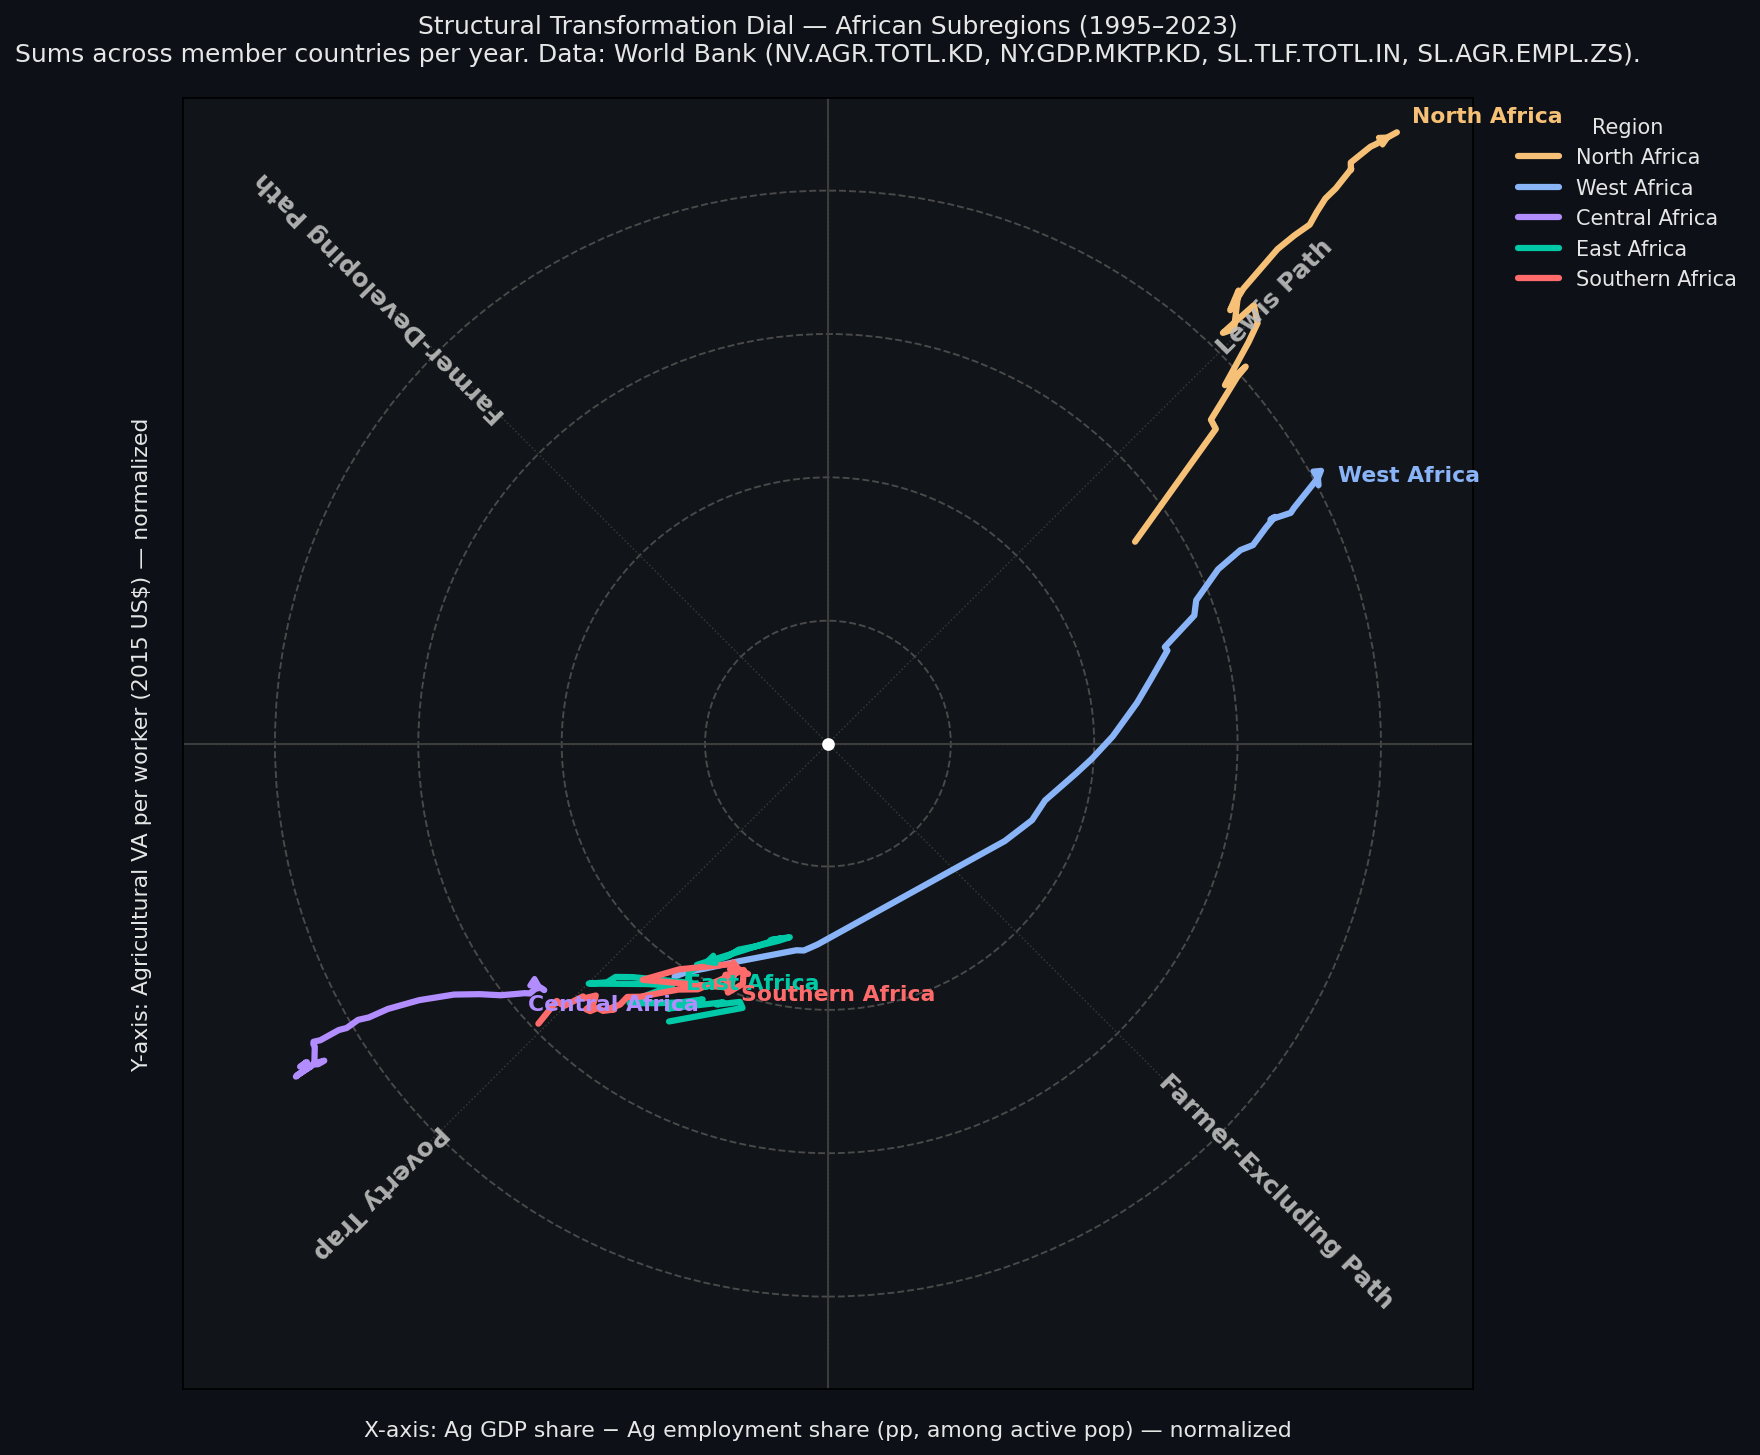

         Region  Years covered     Range
   North Africa             29 1995-2023
    West Africa             29 1995-2023
 Central Africa             29 1995-2023
    East Africa             29 1995-2023
Southern Africa             29 1995-2023


In [ ]:
# %pip install -q requests pandas numpy matplotlib

import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ------------------ Parameters ------------------
START, END = 1995, 2023
MIN_YEARS = 10

# ------------------ African subregion membership (ISO3) ------------------
# UN-style groupings (pragmatic, you can tweak)
AFRICA_SUBREGIONS = {
    "North Africa": {
        "DZA","EGY","LBY","MAR","TUN","ESH","SDN"  # W. Sahara (ESH) optional; Sudan often grouped here
    },
    "West Africa": {
        "BEN","BFA","CIV","CPV","GMB","GHA","GIN","GNB","LBR","MLI","MRT","NER","NGA","SEN","SLE","TGO"
    },
    "Central Africa": {
        "AGO","BDI","CAF","CMR","COD","COG","GNQ","GAB","STP","TCD","RWA"
    },
    "East Africa": {
        "COM","DJI","ERI","ETH","KEN","MDG","MOZ","SDN","SOM","SSD","TZA","UGA"
    },
    "Southern Africa": {
        "BWA","LSO","NAM","ZAF","SWZ","ZMB","ZWE","MOZ"
    },
}
# Note: Some countries appear in more than one common taxonomy (e.g., MOZ, SDN).
# If you want strict partitions, move MOZ to Southern only, SDN to North or East only, etc.

# ------------------ Colors ------------------
PALETTE = {
    "North Africa":   "#F6C177",
    "West Africa":    "#8AB4F8",
    "Central Africa": "#B28DFF",
    "East Africa":    "#00C9A7",
    "Southern Africa":"#FF6B6B",
}

# ------------------ World Bank indicators ------------------
IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",   # Ag value added (constant 2015 US$)
    "GDP_const":  "NY.GDP.MKTP.KD",   # GDP (constant 2015 US$)
    "LAB_FORCE":  "SL.TLF.TOTL.IN",   # Labor force (active population)
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",   # Employment in agriculture (% of total employment)
}

def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value","iso3"])
    rows = [{"Year": int(d["date"]), "Value": d["value"], "iso3": iso3}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

# For each subregion-year: sum GDP, AgVA, LaborForce, AgWorkers; then compute shares and per-worker VA.
def subregion_timeseries(iso_set):
    frames = []
    for iso in sorted(list(iso_set)):
        agva  = wb_indicator(iso, IND["AGVA_const"])
        gdp   = wb_indicator(iso, IND["GDP_const"])
        lf    = wb_indicator(iso, IND["LAB_FORCE"])
        agemp = wb_indicator(iso, IND["AG_EMP_PCT"])
        if any(df.empty for df in [agva, gdp, lf, agemp]):
            continue
        df = (agva.rename(columns={"Value":"AgVA"})
                .merge(gdp.rename(columns={"Value":"GDP"}), on=["iso3","Year"], how="inner")
                .merge(lf.rename(columns={"Value":"LaborForce"}), on=["iso3","Year"], how="inner")
                .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on=["iso3","Year"], how="inner"))
        df = df[(df["Year"]>=START) & (df["Year"]<=END)]
        df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
        if df.empty:
            continue
        df["AgWorkers"] = df["LaborForce"] * (df["AgEmpPct"]/100.0)
        df = df[df["AgWorkers"]>0]
        if df.empty:
            continue
        frames.append(df[["Year","GDP","AgVA","LaborForce","AgWorkers"]])
    if not frames:
        return pd.DataFrame()
    panel = pd.concat(frames, ignore_index=True)
    agg = (panel.groupby("Year", as_index=False)
                .agg({"GDP":"sum","AgVA":"sum","LaborForce":"sum","AgWorkers":"sum"}))
    agg = agg[(agg["GDP"]>0) & (agg["AgVA"]>0) & (agg["LaborForce"]>0) & (agg["AgWorkers"]>0)]
    if agg.shape[0] < MIN_YEARS:
        return pd.DataFrame()
    agg["AgEmp_share"] = (agg["AgWorkers"]/agg["LaborForce"])*100.0
    agg["AgGDP_share"] = (agg["AgVA"]/agg["GDP"])*100.0
    agg["x_gap_pp"]    = agg["AgGDP_share"] - agg["AgEmp_share"]
    agg["AgVA_per_worker"] = agg["AgVA"]/agg["AgWorkers"]
    return agg.sort_values("Year").reset_index(drop=True)

subregion_series = {}
for rname, isos in AFRICA_SUBREGIONS.items():
    s = subregion_timeseries(isos)
    if not s.empty:
        subregion_series[rname] = s

if not subregion_series:
    raise RuntimeError("No valid series for African subregions. Check network/years or adjust membership lists.")

# ------------------ Consistent display scaling across subregions ------------------
def squash(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

all_x = np.concatenate([s["x_gap_pp"].values for s in subregion_series.values()])
all_y = np.concatenate([s["AgVA_per_worker"].values for s in subregion_series.values()])
X_MEAN, X_STD = np.nanmean(all_x), np.nanstd(all_x)
Y_MEAN, Y_STD = np.nanmean(all_y), np.nanstd(all_y)

# ------------------ Plot ------------------
plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})

def draw_concentric(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)

fig = plt.figure(figsize=(11, 11), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")
draw_concentric(ax, radii=np.linspace(0.2,0.9,4))
ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

for txt, deg in [
    ("Farmer-Developing Path", 135),
    ("Lewis Path",               45),
    ("Farmer-Excluding Path",  -45),
    ("Poverty Trap",           -135),
]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=12, rotation=deg, rotation_mode="anchor",
            color="#BFBFBF", weight="bold", alpha=0.9)

for rname, s in subregion_series.items():
    x = squash(s["x_gap_pp"].values, X_MEAN, X_STD)
    y = squash(s["AgVA_per_worker"].values, Y_MEAN, Y_STD)
    col = PALETTE.get(rname, "#E0E0E0")
    ax.plot(x, y, lw=3.0, color=col, solid_capstyle="round", label=rname)
    if len(x) >= 2:
        ax.annotate("", xy=(x[-1],y[-1]), xytext=(x[-2],y[-2]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.6, mutation_scale=10))
    theta = math.atan2(y[-1], x[-1]); off=0.035
    ax.text(x[-1]+off*math.cos(theta), y[-1]+off*math.sin(theta),
            rname, color=col, fontsize=10.5, weight="bold", va="center")

ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("X-axis: Ag GDP share − Ag employment share (pp, among active pop) — normalized", labelpad=15, fontsize=10.5)
ax.set_ylabel("Y-axis: Agricultural VA per worker (2015 US$) — normalized", labelpad=15, fontsize=10.5)
ax.set_title(
    "Structural Transformation Dial — African Subregions (1995–2023)\n"
    "Sums across member countries per year. Data: World Bank (NV.AGR.TOTL.KD, NY.GDP.MKTP.KD, SL.TLF.TOTL.IN, SL.AGR.EMPL.ZS).",
    fontsize=12, pad=18, color="#E6E6E6"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Region")
plt.tight_layout()
plt.show()

# Coverage table
cov = []
for rname, isos in AFRICA_SUBREGIONS.items():
    if rname not in subregion_series:
        cov.append([rname, 0, "-"])
    else:
        s = subregion_series[rname]
        cov.append([rname, s["Year"].nunique(), f"{int(s['Year'].min())}-{int(s['Year'].max())}"])
print(pd.DataFrame(cov, columns=["Region","Years covered","Range"]).to_string(index=False))


 Country ISO3     Yield code         Fert code  Start  End  #Years
 Morocco  MAR AG.YLD.CREL.KG AG.CON.FERT.PT.ZS   1995 2023      29
   Egypt  EGY AG.YLD.CREL.KG AG.CON.FERT.PT.ZS   1995 2023      29
   Ghana  GHA AG.YLD.CREL.KG    AG.CON.FERT.ZS   1995 2023      29
   India  IND AG.YLD.CREL.KG AG.CON.FERT.PT.ZS   1995 2023      29
  Brazil  BRA AG.YLD.CREL.KG AG.CON.FERT.PT.ZS   1995 2023      29
Ethiopia  ETH AG.YLD.CREL.KG    AG.CON.FERT.ZS   1995 2023      29


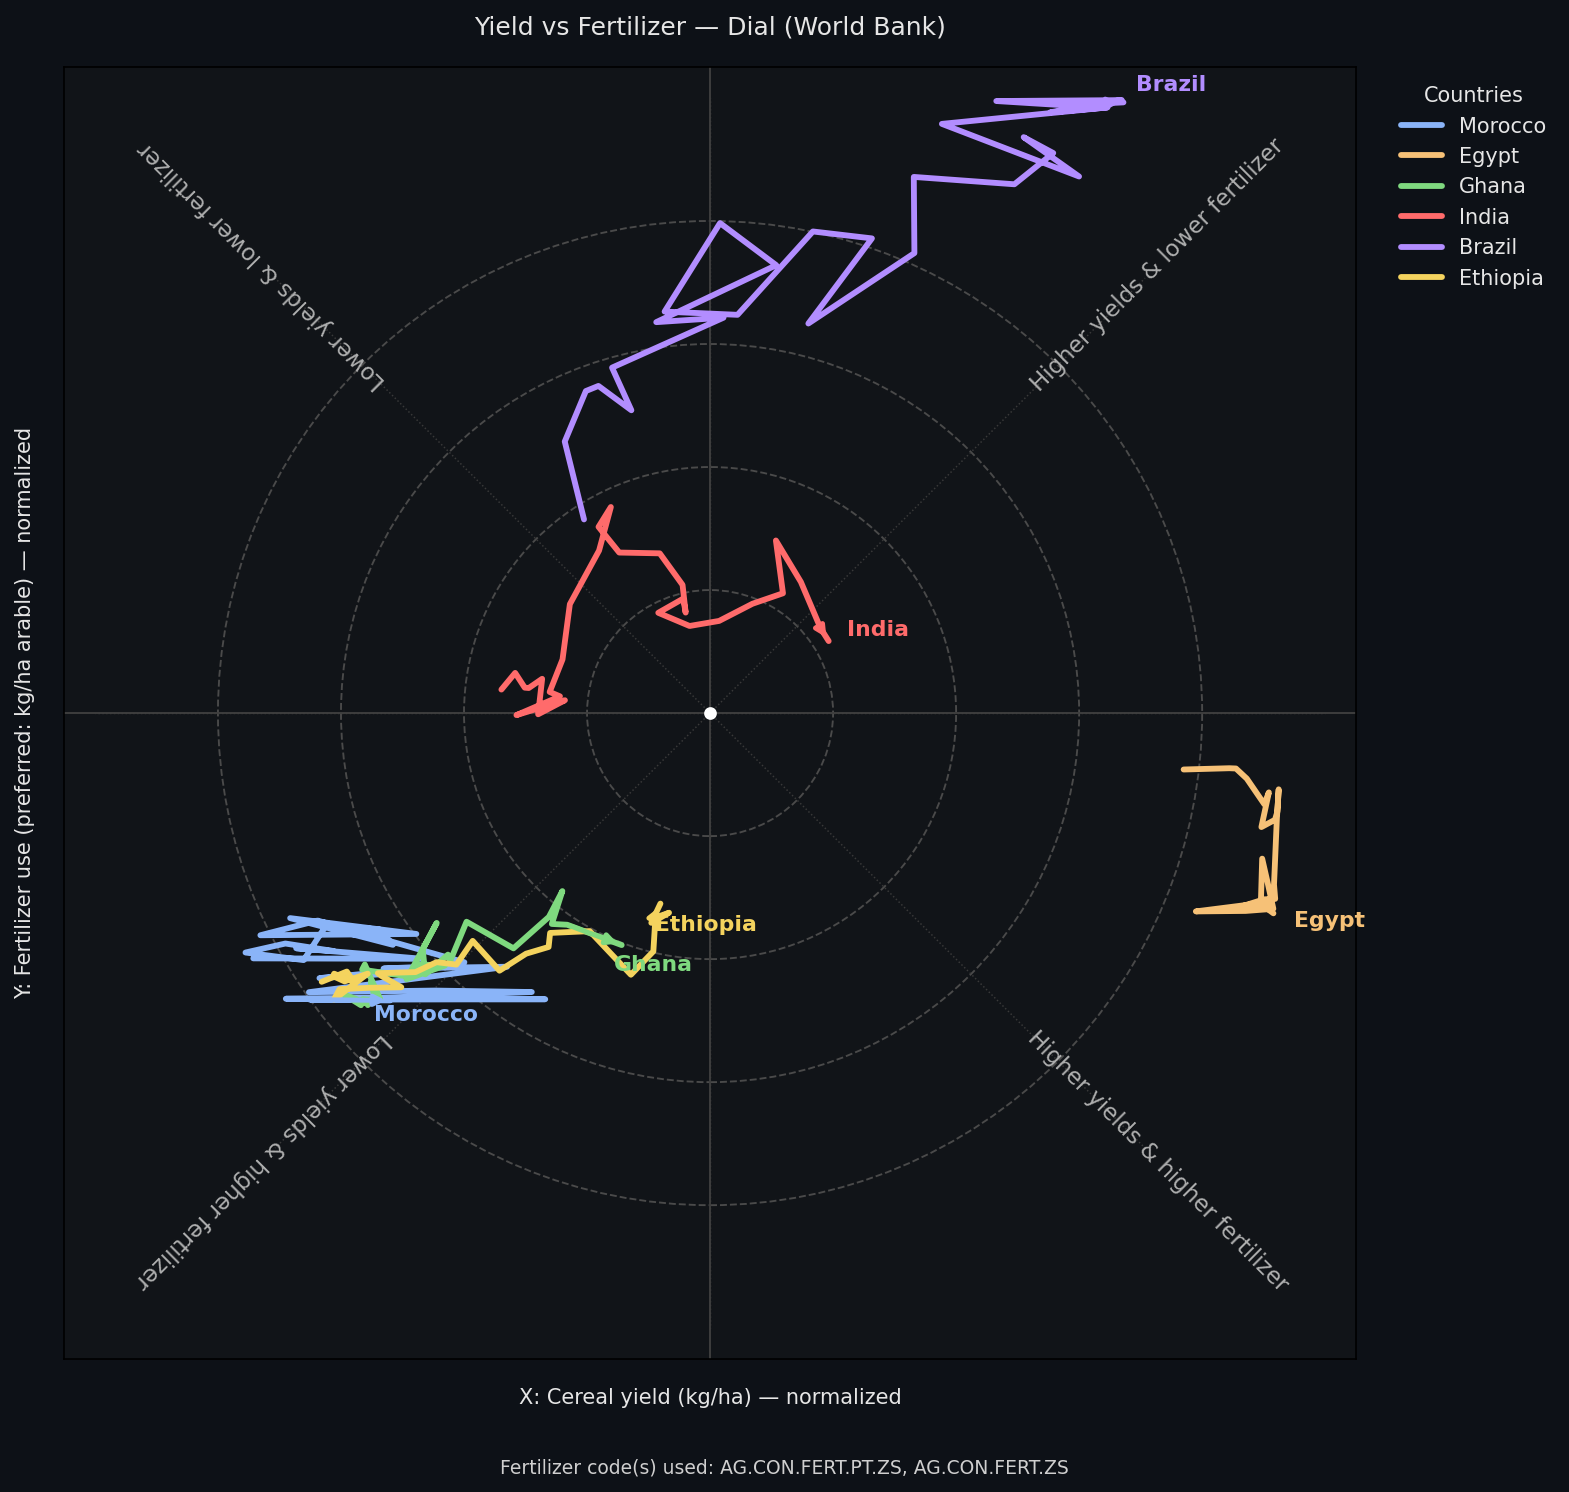

In [ ]:
# %pip install -q requests pandas numpy matplotlib
import time, requests, numpy as np, pandas as pd, matplotlib.pyplot as plt, math
from matplotlib.patches import Circle

START, END = 1995, 2023
MIN_YEARS = 8

COUNTRIES = {
    "Morocco":"MAR","Egypt":"EGY","Ghana":"GHA","India":"IND","Brazil":"BRA", "Ethiopia":"ETH"
}

# ---- robust indicator fetching ----
def wb_get(url, retries=4, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, ind, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{ind}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value","iso3"])
    rows = [{"Year": int(d["date"]), "Value": d["value"], "iso3": iso3}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

def fetch_first_available(iso3, code_list):
    """Try a list of WB codes; return the first non-empty series."""
    for code in code_list:
        df = wb_indicator(iso3, code)
        if not df.empty:
            return df, code
    return pd.DataFrame(), None

# Preferred + fallbacks (some countries miss the primary code)
YIELD_CODES = ["AG.YLD.CREL.KG"]              # cereal yield (kg/ha)
FERT_CODES  = ["AG.CON.FERT.PT.ZS",           # kg/ha of arable land (primary)
               "AG.CON.FERT.KG",              # fertilizer consumption (tons) -> not per ha, but better than nothing
               "AG.CON.FERT.ZS"]              # % of fertilizer production (least ideal)
              # We’ll use per-ha if available; otherwise we still plot (noted in legend).

def build_country_series(iso3):
    yld_df, yld_code = fetch_first_available(iso3, YIELD_CODES)
    fert_df, fert_code = fetch_first_available(iso3, FERT_CODES)
    if yld_df.empty or fert_df.empty:
        return pd.DataFrame(), yld_code, fert_code
    yld_df = yld_df.rename(columns={"Value":"YIELD"})[["Year","YIELD"]]
    fert_df = fert_df.rename(columns={"Value":"FERT"})[["Year","FERT"]]
    df = yld_df.merge(fert_df, on="Year", how="inner")
    df = df[(df["Year"]>=START)&(df["Year"]<=END)].dropna()
    return df.sort_values("Year").reset_index(drop=True), yld_code, fert_code

# ---- assemble series ----
series = {}
meta = []  # coverage table
for name, iso in COUNTRIES.items():
    df, ycode, fcode = build_country_series(iso)
    if df.shape[0] >= MIN_YEARS:
        series[name] = df
        meta.append([name, iso, ycode or "-", fcode or "-", df["Year"].min(), df["Year"].max(), df.shape[0]])
    else:
        meta.append([name, iso, ycode or "-", fcode or "-", "-", "-", 0])

print(pd.DataFrame(meta, columns=["Country","ISO3","Yield code","Fert code","Start","End","#Years"]).to_string(index=False))
if not series:
    raise RuntimeError("No country had sufficient overlapping data for the chosen indicators.")

# ---- display scaling (squash) ----
def squash(v, mean, std, scale=0.75):
    z = (v - mean) / max(std, 1e-9)
    return np.tanh(scale*z)

allx = np.concatenate([s["YIELD"].values for s in series.values()])
ally = np.concatenate([s["FERT"].values  for s in series.values()])
X_MEAN, X_STD = np.nanmean(allx), np.nanstd(allx)
Y_MEAN, Y_STD = np.nanmean(ally), np.nanstd(ally)

# ---- plot ----
plt.rcParams.update({
    "axes.facecolor": "#111418",
    "figure.facecolor": "#0D1117",
    "text.color": "#E6E6E6",
    "axes.labelcolor": "#E6E6E6",
})
palette = ["#8AB4F8","#F6C177","#7FD97F","#FF6B6B","#B28DFF","#F4D35E","#00C9A7","#FF9F1C"]

fig = plt.figure(figsize=(10.5,10.5), dpi=150)
ax = plt.gca()
ax.set_aspect("equal"); ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
ax.set_facecolor("#111418")

# background rings
def rings(ax, radii=(0.2,0.4,0.6,0.8), color="#4A4A4A", lw=0.9, ls="--"):
    for r in radii:
        ax.add_patch(Circle((0,0), r, fill=False, color=color, lw=lw, ls=ls, zorder=0))
    for ang in np.deg2rad([0,45,90,135,180,225,270,315]):
        ax.plot([0, math.cos(ang)], [0, math.sin(ang)], ls=":", lw=0.7, color="#3A3A3A", zorder=0)
rings(ax); ax.axhline(0, color="#3F3F3F", lw=0.9); ax.axvline(0, color="#3F3F3F", lw=0.9)

# quadrant labels (optional, keep same as dial style)
for txt, deg in [("Lower yields & lower fertilizer",135),
                 ("Higher yields & lower fertilizer",45),
                 ("Lower yields & higher fertilizer",-135),
                 ("Higher yields & higher fertilizer",-45)]:
    r=1.03; rad=np.deg2rad(deg)
    ax.text(r*math.cos(rad), r*math.sin(rad), txt, ha="center", va="center",
            fontsize=11, rotation=deg, rotation_mode="anchor", color="#BFBFBF", alpha=0.9)

for i,(name, df) in enumerate(series.items()):
    col = palette[i % len(palette)]
    x = squash(df["YIELD"].values, X_MEAN, X_STD)
    y = squash(df["FERT"].values,  Y_MEAN, Y_STD)
    ax.plot(x, y, lw=2.8, color=col, solid_capstyle="round", label=name)
    if len(x) >= 2:
        ax.annotate("", xy=(x[-1],y[-1]), xytext=(x[-2],y[-2]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.4, mutation_scale=10))
    theta = math.atan2(y[-1], x[-1]); off=0.035
    ax.text(x[-1]+off*math.cos(theta), y[-1]+off*math.sin(theta),
            name, color=col, fontsize=10.5, weight="bold", va="center")

ax.scatter([0],[0], s=26, color="#FFFFFF", zorder=5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("X: Cereal yield (kg/ha) — normalized", labelpad=14)
ax.set_ylabel("Y: Fertilizer use (preferred: kg/ha arable) — normalized", labelpad=14)

# Footnote clarifies fallback if per-ha missing
used_codes = set([row[3] for row in meta if row[-1] != 0])
foot = "Fertilizer code(s) used: " + ", ".join(sorted(used_codes))
ax.set_title("Yield vs Fertilizer — Dial (World Bank)", fontsize=12, pad=16)
plt.figtext(0.5, 0.02, foot, ha="center", va="center", fontsize=9, color="#CFCFCF")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Countries")
plt.tight_layout()
plt.show()


In [ ]:
# %%capture
# !pip install plotly requests pandas numpy

import math, time, requests
import numpy as np
import pandas as pd
import plotly.graph_objects as go

START, END = 1995, 2023
MIN_YEARS = 8

AFR = {
    'Algeria': 'DZA', 'Angola': 'AGO', 'Benin': 'BEN', 'Botswana': 'BWA', 'Burkina Faso': 'BFA',
    'Burundi': 'BDI', 'Cabo Verde': 'CPV', 'Cameroon': 'CMR', 'Central African Republic': 'CAF',
    'Chad': 'TCD', 'Comoros': 'COM', 'Congo (Brazzaville)': 'COG', 'Congo (Kinshasa)': 'COD',
    "Côte d'Ivoire": 'CIV', 'Djibouti': 'DJI', 'Egypt': 'EGY', 'Equatorial Guinea': 'GNQ',
    'Eritrea': 'ERI', 'Eswatini': 'SWZ', 'Ethiopia': 'ETH', 'Gabon': 'GAB', 'Gambia': 'GMB',
    'Ghana': 'GHA', 'Guinea': 'GIN', 'Guinea-Bissau': 'GNB', 'Kenya': 'KEN', 'Lesotho': 'LSO',
    'Liberia': 'LBR', 'Libya': 'LBY', 'Madagascar': 'MDG', 'Malawi': 'MWI', 'Mali': 'MLI',
    'Mauritania': 'MRT', 'Mauritius': 'MUS', 'Morocco': 'MAR', 'Mozambique': 'MOZ',
    'Namibia': 'NAM', 'Niger': 'NER', 'Nigeria': 'NGA', 'Rwanda': 'RWA', 'Sao Tome and Principe': 'STP',
    'Senegal': 'SEN', 'Seychelles': 'SYC', 'Sierra Leone': 'SLE', 'Somalia': 'SOM',
    'South Africa': 'ZAF', 'South Sudan': 'SSD', 'Sudan': 'SDN', 'Tanzania': 'TZA',
    'Togo': 'TGO', 'Tunisia': 'TUN', 'Uganda': 'UGA', 'Zambia': 'ZMB', 'Zimbabwe': 'ZWE'
}

INITIAL_COUNTRIES = {"Morocco", "Egypt", "South Africa", "Ethiopia", "Ghana"}

IND = {
    "AGVA_const": "NV.AGR.TOTL.KD",
    "GDP_const":  "NY.GDP.MKTP.KD",
    "LAB_FORCE":  "SL.TLF.TOTL.IN",
    "AG_EMP_PCT": "SL.AGR.EMPL.ZS",
    "AGVA_ZS":    "NV.AGR.TOTL.ZS",
}

def wb_get(url, retries=5, pause=0.5):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=45)
            if r.status_code == 200:
                return r.json()
        except Exception:
            pass
        time.sleep(pause)
    return None

def wb_indicator(iso3, code, start=START, end=END):
    url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/{code}"
           f"?date={start}:{end}&format=json&per_page=4000")
    js = wb_get(url)
    if not js or len(js) < 2 or js[1] is None:
        return pd.DataFrame(columns=["Year","Value","iso3"])
    rows = [{"Year": int(d["date"]), "Value": d["value"], "iso3": iso3}
            for d in js[1] if d.get("value") is not None]
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df.dropna()

# Build country series
series = {}
for name, iso in AFR.items():
    agva  = wb_indicator(iso, IND["AGVA_const"])
    gdp   = wb_indicator(iso, IND["GDP_const"])
    lf    = wb_indicator(iso, IND["LAB_FORCE"])
    agemp = wb_indicator(iso, IND["AG_EMP_PCT"])
    agvaz = wb_indicator(iso, IND["AGVA_ZS"])
    if any(df.empty for df in [agva, gdp, lf, agemp, agvaz]):
        continue
    df = (agva.rename(columns={"Value":"AgVA"})
              .merge(gdp.rename(columns={"Value":"GDP"}), on=["iso3","Year"], how="inner")
              .merge(lf.rename(columns={"Value":"LaborForce"}), on=["iso3","Year"], how="inner")
              .merge(agemp.rename(columns={"Value":"AgEmpPct"}), on=["iso3","Year"], how="inner")
              .merge(agvaz.rename(columns={"Value":"AgGDPpct"}), on=["iso3","Year"], how="inner"))
    df = df[(df["Year"]>=START) & (df["Year"]<=END)]
    df = df[(df["GDP"]>0) & (df["AgVA"]>0) & (df["LaborForce"]>0)]
    if df.empty:
        continue
    df["AgWorkers"]   = df["LaborForce"] * (df["AgEmpPct"]/100.0)
    df = df[df["AgWorkers"]>0]
    if df.shape[0] < 8:
        continue
    df["AgEmp_share"] = (df["AgWorkers"]/df["LaborForce"])*100.0
    df["AgGDP_share"] = df["AgGDPpct"]
    df["X_raw"] = df["AgGDP_share"] - df["AgEmp_share"]
    df["Y_raw"] = df["AgVA"] / df["AgWorkers"]
    series[name] = df.sort_values("Year").reset_index(drop=True)

if not series:
    raise RuntimeError("No country had sufficient data.")

# Normalize
def squash(v, mean, std, scale=0.75):
    z = (v - mean) / (std if std and std>0 else 1e-9)
    return np.tanh(scale * z)

allx = np.concatenate([s["X_raw"].values for s in series.values()])
ally = np.concatenate([s["Y_raw"].values for s in series.values()])
X_M, X_S = float(np.nanmean(allx)), float(np.nanstd(allx))
Y_M, Y_S = float(np.nanmean(ally)), float(np.nanstd(ally))

# Figure
fig = go.Figure()

# background
for r in [0.2, 0.4, 0.6, 0.8]:
    fig.add_shape(type="circle", x0=-r, y0=-r, x1=r, y1=r,
                  line=dict(color="rgba(200,200,200,0.3)", dash="dash"))
fig.add_shape(type="line", x0=-1, y0=0, x1=1, y1=0, line=dict(color="rgba(180,180,180,0.35)"))
fig.add_shape(type="line", x0=0, y0=-1, x1=0, y1=1, line=dict(color="rgba(180,180,180,0.35)"))
for txt, x, y, xa, ya in [
    ("Farmer-Developing Path",  0.0 - 0.01,  +1.02, "right", "bottom"),
    ("Lewis Path",              +1.02,       0.0 + 0.01, "left",  "bottom"),
    ("Farmer-Excluding Path",   0.0 + 0.01,  -1.02, "left",  "top"),
    ("Poverty Trap",            -1.02,       0.0 - 0.01, "right", "top"),
]:
    fig.add_annotation(text=txt, x=x, y=y, showarrow=False,
                       font=dict(size=12, color="rgba(180,180,180,0.9)"),
                       xanchor=xa, yanchor=ya)

# Traces
ordered_names = sorted(series.keys())
line_trace_idx = []   # store indexes of line traces (for buttons)
arrow_trace_idx = []  # store indexes of arrow traces

for name in ordered_names:
    df = series[name]
    x = squash(df["X_raw"].to_numpy(), X_M, X_S)
    y = squash(df["Y_raw"].to_numpy(), Y_M, Y_S)
    visible_state = True if name in INITIAL_COUNTRIES else "legendonly"  # <-- key line

    # line+markers
    fig.add_trace(go.Scatter(
        x=x, y=y, mode="lines+markers",
        line=dict(width=2), marker=dict(size=5),
        name=name, visible=visible_state,
        hovertemplate=(f"<b>{name}</b><br>"
                       "Year: %{customdata[0]}<br>"
                       "X (pp, norm): %{x:.3f}<br>"
                       "Y ($/worker, norm): %{y:.3f}<extra></extra>"),
        customdata=np.column_stack([df["Year"].values])
    ))
    line_trace_idx.append(len(fig.data) - 1)

    # arrow at end (no legend entry)
    fig.add_trace(go.Scatter(
        x=[x[-1]], y=[y[-1]], mode="markers",
        marker_symbol="triangle-up", marker_size=10,
        name=f"{name} (end)", showlegend=False,
        visible=(True if name in INITIAL_COUNTRIES else False), hoverinfo="skip", opacity=0.7
    ))
    arrow_trace_idx.append(len(fig.data) - 1)

# Buttons: Select/Unselect all (keep legend items present)
vis_all = []
vis_none = []
for i in range(len(fig.data)):
    if i in line_trace_idx:
        vis_all.append(True)             # show curve
        vis_none.append("legendonly")    # keep in legend but hide on canvas
    else:
        vis_all.append(True)             # show arrow
        vis_none.append(False)           # hide arrow

fig.update_layout(
    updatemenus=[dict(
        type="buttons", direction="right",
        x=0.5, y=1.12, xanchor="center", yanchor="bottom",
        buttons=[
            dict(label="Select All",   method="update", args=[{"visible": vis_all}]),
            dict(label="Unselect All", method="update", args=[{"visible": vis_none}]),
        ]
    )]
)

fig.update_layout(
    width=900, height=900, template="plotly_dark",
    xaxis=dict(range=[-1.05,1.05], title="X: Ag share of GDP − Ag share of employment (pp, active pop) — normalized",
               zeroline=False, showgrid=False, visible=False),
    yaxis=dict(range=[-1.05,1.05], title="Y: Agricultural value added per worker (2015 US$, normalized)",
               zeroline=False, showgrid=False, visible=False),
    title=("Structural Transformation Dial — African Countries (1995–2023)<br>"
           "<sup>Data: World Bank NV.AGR.TOTL.ZS, SL.AGR.EMPL.ZS, NV.AGR.TOTL.KD, SL.TLF.TOTL.IN."
           " Initial selection: Morocco, Egypt, South Africa, Ethiopia, Ghana.</sup>"),
    legend=dict(orientation="v", yanchor="top", y=0.99, xanchor="left", x=1.02),
    margin=dict(l=60, r=250, t=120, b=60)
)

# Save HTML
html_path = "/content/africa_dial_interactive_5start_legendonly.html"
fig.write_html(html_path, include_plotlyjs="cdn")
print("Saved:", html_path)


Saved: /content/africa_dial_interactive_5start_legendonly.html


In [ ]:
from IPython.display import IFrame

html_path = "/content/africa_dial_interactive_5start_legendonly.html"
IFrame(src=html_path, width=900, height=900)